# Stage 01 — Ratings

Computes `ExpectedMf` (expected Fantamedia performance for the upcoming season) and prepares the output for Stage 2.

**Input:** `data/intermediate/{SEASON}/data_preprocess_merge.xlsx` (Stage 0 output)
**Output:** `data/intermediate/{SEASON}/output_rp.csv`

**Pipeline position:** Stage 00 → **Stage 01** → Stage 02 (distribution / regressors)

In [1]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial

# Resolve repo root (notebook may run from pipeline/ or repo root)
BASE = os.getcwd()
if os.path.basename(BASE) == 'pipeline':
    BASE = os.path.abspath(os.path.join(BASE, '..'))
os.chdir(BASE)

# Load centralized config
import yaml
with open('pipeline/config/stage01.yaml') as _f:
    CFG = yaml.safe_load(_f)

# Paths
SEASON = "25-26"
INTER_DIR = f"data/intermediate/{SEASON}"
INPUT_PATH = f"{INTER_DIR}/data_preprocess_merge.xlsx"
OUTPUT_PATH = f"{INTER_DIR}/output_rp.csv"

# Roles & colors from config
roles = CFG['roles']['major']
roles_m = CFG['roles']['sub']
role_colors = CFG['role_colors']
main_colors = {'P': '#FFB74D', 'D': '#64B5F6', 'C': '#81C784', 'A': '#E57373'}

def get_role_color(role):
    return role_colors.get(role, '#CCCCCC')

# Fitting params from config
seasons = None  # extracted after df load
matches_filter = [CFG['matches_filters'][r] for r in roles_m]
fvm_curve_min_games = CFG['fitting']['fvm_min_games']
age_pred_min_games = CFG['fitting']['age_min_games']
season_decay = CFG['fitting']['season_decay']

# Blend params — will be overridden by tuning step (Cell 5)
# Kept here as fallback defaults
w_fvm = 0.8
age_modifier_weight = CFG['fitting'].get('age_mod', 0.2)

print(f"Config loaded: {len(roles_m)} sub-roles, {len(roles)} major roles")
print(f"FVM min games={fvm_curve_min_games}, Age min games={age_pred_min_games}, Season decay={season_decay}")

Config loaded: 12 sub-roles, 4 major roles
FVM min games=24, Age min games=16, Season decay=0.3


## Load data

Reads the Stage 0 output (`data_preprocess_merge.xlsx`), which contains:
- Player roster: `Id`, `Role`, `Role_M`, `Name`, `Squad`, `Price`, `Age`, `FVM`
- Historical stats: `Pg{season}`, `Mv{season}`, `Mf{season}`, `FVM{season}` for each available season
- Historical FVM columns are only available from season 22-23 onward


In [2]:
df = pd.read_excel(INPUT_PATH)
seasons = sorted(set([col[2:] for col in df.columns if col.startswith("Pg")]), reverse=True)
print('Seasons extracted:', seasons)
print(df.shape)


Seasons extracted: ['24_25', '23_24', '22_23', '21_22', '20_21', '19_20']
(532, 35)


## FVM Model Tuning

Before computing ExpectedMf, we run an automated tuning step that:
1. Trains FVM models under multiple configurations on all-but-last FVM season
2. Validates on the most recent FVM season (hold-out)
3. Selects the best config by lowest MAE
4. Retrains on all available FVM data

This ensures the FVM model is objectively selected based on predictive performance,
not manual guesswork. The full report is saved to `fvm_tuning_report.json`.

**Override:** Set `OVERRIDE_CONFIG` below to force a specific configuration.

In [3]:
import sys
sys.path.insert(0, BASE)  # ensure repo root is on path

from pipeline.fvm_tuning import (
    run_tuning, CANDIDATE_CONFIGS, ROLE_BLEND_WEIGHTS, FVM_SCALE,
    resolve_w_fvm, resolve_transform, resolve_fvm_scale, transform_fvm
)

# Override config loaded from YAML (set to null in YAML for automatic selection)
OVERRIDE_CONFIG = CFG.get('override_config')

print("=== Running FVM Model Tuning ===")
report_path = run_tuning(INPUT_PATH, INTER_DIR)

# Load the tuning report
with open(report_path) as f:
    tuning_report = json.load(f)

best_name = tuning_report['best_config_name']
best_cfg = tuning_report['best_config']

# Apply override if set
if OVERRIDE_CONFIG and OVERRIDE_CONFIG in CANDIDATE_CONFIGS:
    print(f"Overriding to config: {OVERRIDE_CONFIG}")
    best_name = OVERRIDE_CONFIG
    best_cfg = CANDIDATE_CONFIGS[OVERRIDE_CONFIG]
    # Retrain with override config
    import pandas as pd
    import numpy as np
    from pipeline.fvm_tuning import (
        load_stage0, has_fvm_for_seasons, build_role_subsets,
        collect_fvm_pairs, fit_fvm_model, fit_age_curve,
        compute_expected_mf, MATCHES_FILTERS, ROLES_M
    )
    df_tune, seasons_tune = load_stage0(INPUT_PATH)
    fvm_seasons = has_fvm_for_seasons(df_tune, seasons_tune)
    role_subsets = build_role_subsets(df_tune)
    transform = best_cfg.get('transform', 'linear')
    final_coefs = {}
    for role in ROLES_M:
        data = collect_fvm_pairs(role_subsets[role], fvm_seasons)
        role_transform = resolve_transform(transform, role)
        final_coefs[role] = fit_fvm_model(data, best_cfg['method'], best_cfg['fvm_cap'], role_transform)
    tuning_report['best_config_name'] = best_name
    # Serialize w_fvm for JSON (may be dict)
    cfg_serial = dict(best_cfg)
    if isinstance(cfg_serial['w_fvm'], dict):
        cfg_serial['w_fvm'] = dict(cfg_serial['w_fvm'])
    tuning_report['best_config'] = cfg_serial
    tuning_report['final_coefs'] = {
        r: {'slope': float(c[0]), 'intercept': float(c[1])} if c is not None else None
        for r, c in final_coefs.items()
    }
    # Save updated report
    with open(report_path, 'w') as f:
        json.dump(tuning_report, f, indent=2)

# Extract parameters from selected config
w_fvm = best_cfg['w_fvm']
age_modifier_weight = best_cfg['age_mod']
fvm_method = best_cfg['method']
fvm_cap = best_cfg['fvm_cap']
fvm_transform = best_cfg.get('transform', 'linear')
fvm_scale = best_cfg.get('fvm_scale', 1.0)

print(f"Selected config: {best_name}")
print(f"  method={best_cfg['method']}, transform={best_cfg.get('transform','linear')}, "
      f"fvm_cap={best_cfg['fvm_cap']}, w_fvm={best_cfg['w_fvm']}, age_mod={best_cfg['age_mod']}, "
      f"fvm_scale={fvm_scale}")
print(f"Hold-out comparison:")
for name, comp in tuning_report['config_comparison'].items():
    marker = ' <-- best' if name == best_name else ''
    print(f"  {name:<22s}: MAE={comp['holdout_mae']:.4f}  RMSE={comp['holdout_rmse']:.4f}  n={comp['holdout_n']}{marker}")

# Extract final coefficients for use in the notebook
fvm_coefs = {}
for role, coef in tuning_report['final_coefs'].items():
    if coef:
        fvm_coefs[role] = np.array([coef['slope'], coef['intercept']])
    else:
        fvm_coefs[role] = None

print(f"Final ExpectedMf stats:")
for role, st in tuning_report['expectedmf_stats'].items():
    print(f"  {role}: mean={st['mean']:.2f} std={st['std']:.3f} p5={st['p5']:.2f} p95={st['p95']:.2f}")





=== Running FVM Model Tuning ===
Seasons available: ['24_25', '23_24', '22_23', '21_22', '20_21', '19_20']
Seasons with FVM:  ['24_25', '23_24', '22_23']
Candidate configs: ['linear_baseline', 'linear_w0.9', 'linear_w1.0', 'linear_cap200', 'linear_cap200_w0.9', 'theilsen', 'theilsen_cap200', 'sqrt_baseline', 'sqrt_role_weights', 'sqrt_pd_linear_ac']



  linear_baseline       : MAE=0.2686 RMSE=0.3624 n=159
  linear_w0.9           : MAE=0.2686 RMSE=0.3624 n=159
  linear_w1.0           : MAE=0.2686 RMSE=0.3624 n=159
  linear_cap200         : MAE=0.3046 RMSE=0.4524 n=159


  linear_cap200_w0.9    : MAE=0.3046 RMSE=0.4524 n=159
  theilsen              : MAE=0.3003 RMSE=0.4031 n=159
  theilsen_cap200       : MAE=0.3286 RMSE=0.4718 n=159
  sqrt_baseline         : MAE=0.2803 RMSE=0.3751 n=159
  sqrt_role_weights     : MAE=0.2803 RMSE=0.3751 n=159


  sqrt_pd_linear_ac     : MAE=0.2758 RMSE=0.3704 n=159

Best config: linear_baseline (MAE=0.26864982342135996)

Report saved: data/intermediate/25-26/fvm_tuning_report.json
ExpectedMf stats:
  P: mean=4.79 std=0.186 p5=4.67 p95=5.28
  D: mean=5.99 std=0.202 p5=5.85 p95=6.24
  C: mean=6.32 std=0.250 p5=6.06 p95=6.79
  A: mean=6.65 std=0.275 p5=6.32 p95=7.24
Tuned ExpectedMf saved: data/intermediate/25-26/expected_mf_tuned.csv
Overriding to config: sqrt_pd_linear_ac


Selected config: sqrt_pd_linear_ac
  method=linear, transform={'P': 'sqrt', 'D': 'sqrt', 'C': 'linear', 'A': 'linear'}, fvm_cap=None, w_fvm={'P': 0.8, 'D': 0.7, 'C': 0.8, 'A': 0.8}, age_mod=0.4, fvm_scale={'P': 1.0, 'D': 1.05, 'C': 1.05, 'A': 1.05}
Hold-out comparison:
  linear_baseline       : MAE=0.2686  RMSE=0.3624  n=159
  linear_w0.9           : MAE=0.2686  RMSE=0.3624  n=159
  linear_w1.0           : MAE=0.2686  RMSE=0.3624  n=159
  linear_cap200         : MAE=0.3046  RMSE=0.4524  n=159
  linear_cap200_w0.9    : MAE=0.3046  RMSE=0.4524  n=159
  theilsen              : MAE=0.3003  RMSE=0.4031  n=159
  theilsen_cap200       : MAE=0.3286  RMSE=0.4718  n=159
  sqrt_baseline         : MAE=0.2803  RMSE=0.3751  n=159
  sqrt_role_weights     : MAE=0.2803  RMSE=0.3751  n=159
  sqrt_pd_linear_ac     : MAE=0.2758  RMSE=0.3704  n=159 <-- best
Final ExpectedMf stats:
  P: mean=4.79 std=0.186 p5=4.67 p95=5.28
  D: mean=5.99 std=0.202 p5=5.85 p95=6.24
  C: mean=6.32 std=0.250 p5=6.06 p95=6.79
 

## Data overview

Distribution of Age, Role, Price, and FVM across the roster.

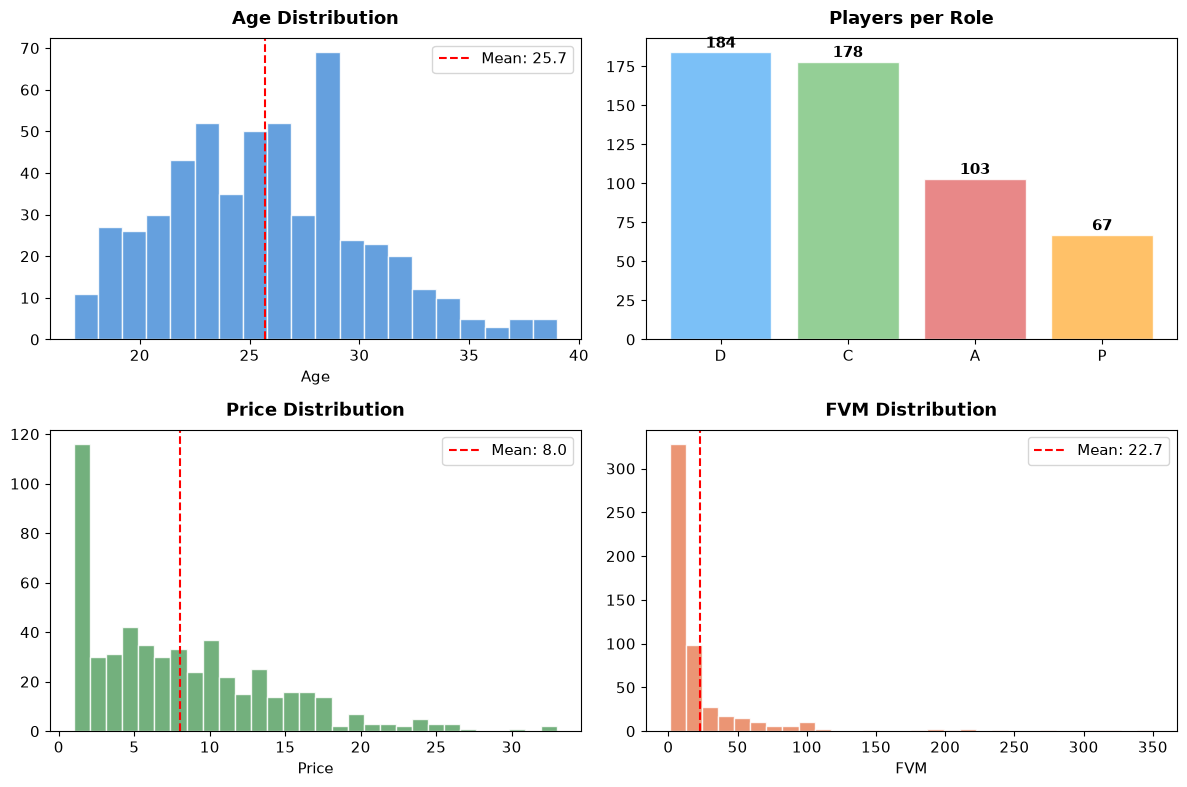

In [4]:
plt.rcParams.update({'figure.figsize': (12, 8), 'font.size': 11})
fig, axes = plt.subplots(2, 2)

# Age distribution
axes[0, 0].hist(df['Age'].dropna(), bins=20, color='#4A90D9', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Age Distribution', fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Age')
axes[0, 0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
axes[0, 0].legend()

# Players per Role
role_counts = df['Role'].value_counts()
colors_bar = [main_colors.get(r, '#CCCCCC') for r in role_counts.index]
bars = axes[0, 1].bar(range(len(role_counts)), role_counts.values, color=colors_bar, edgecolor='white', alpha=0.85)
axes[0, 1].set_xticks(range(len(role_counts)))
axes[0, 1].set_xticklabels(role_counts.index)
axes[0, 1].set_title('Players per Role', fontweight='bold', pad=10)
for bar, val in zip(bars, role_counts.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(val), ha='center', fontweight='bold')

# Price distribution
axes[1, 0].hist(df['Price'].dropna(), bins=30, color='#5BA266', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('Price Distribution', fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Price')
axes[1, 0].axvline(df['Price'].mean(), color='red', linestyle='--', label=f"Mean: {df['Price'].mean():.1f}")
axes[1, 0].legend()

# FVM distribution
axes[1, 1].hist(df['FVM'].dropna(), bins=30, color='#E8835C', edgecolor='white', alpha=0.85)
axes[1, 1].set_title('FVM Distribution', fontweight='bold', pad=10)
axes[1, 1].set_xlabel('FVM')
axes[1, 1].axvline(df['FVM'].mean(), color='red', linestyle='--', label=f"Mean: {df['FVM'].mean():.1f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## Compute ratings

The expected performance for the upcoming season (`ExpectedMf`) is computed as a **weighted blend** of two independent signals:

```
ExpectedMf = w_fvm × FVM_pred + (1 - w_fvm) × hist_perf
```

### Tuning-driven parameters

The FVM model configuration (method, fvm_cap, w_fvm, age_mod) is selected automatically
by the tuning step above. It trains on all-but-last FVM season and validates on the hold-out season.

### FVM → Mf regression

For each Role_M, a regression is fitted on pooled same-season data (FVM_t → Mf_t, not lagged).
Each observation is weighted by `clip(Pg, 0, 38)`.

- **`fvm_cap`**: if set, caps FVM values during training to prevent extreme outliers from flattening the slope.
  Predictions use the actual (uncapped) FVM value.
- **`method`**: `linear` (weighted OLS) or `theilsen` (robust median slope).

### Historical performance + age delta

If the player has valid data from the most recent season (`Pg ≥ age_pred_min_games`):

```
hist_perf = Mf_last + age_modifier_weight × age_delta
```

- **`Mf_last`**: the player's actual Mf from the last season
- **`age_delta`**: expected performance change from age N-1 to age N (quadratic age curve)
- **`age_modifier_weight`**: how much of the age curve delta to apply

If no recent data, falls back to the age curve prediction, then to FVM prediction.

### Role merge: Ds → Dd

Ds (terzino sinistro) and Dd (terzino destro) are functionally equivalent wing-backs.
Merged for training to increase sample size. At prediction time, a player's primary role
is used (first entry in `Role_M`).

In [5]:
# The FVM models, blend weights, and age parameters are now set by the tuning step above.
# This cell builds age curves and computes the final ExpectedMf using tuned coefficients.

# Subset by Role_M – merge Ds into Dd
df_m = []
for role in roles_m:
    if role == 'Dd':
        df_temp = df[df['Role_M'].str.split(';').str[0].isin(['Dd','Ds'])]
    else:
        df_temp = df[df['Role_M'].str.split(';').str[0] == role]
    df_m.append(df_temp)

# Fit age-performance curves (used for age delta modifier)
stats_models = []
for i, df_temp in enumerate(df_m):
    players = []
    for _, row in df_temp.iterrows():
        for k, s in enumerate(seasons):
            if row['Pg'+s] >= matches_filter[i]:
                season_weight = np.exp(-season_decay * k)
                players.append({'Name':row['Name'], 'Age':row['Age']-1-k, 'MfPerformance':row['Mf'+s], 'season_weight': season_weight})
    new_df = pd.DataFrame(players)
    new_df = new_df[new_df['Age'] <= 34]
    if len(new_df) > 0:
        age_groups = new_df.groupby('Age').apply(lambda g: np.average(g['MfPerformance'], weights=g['season_weight']))
    else:
        age_groups = pd.Series(dtype=float)
    if len(age_groups) >= 3:
        p = Polynomial.fit(age_groups.index, age_groups.values, deg=2)
        stats_models.append(p)
    else:
        stats_models.append(None)

# FVM models are already fitted by the tuning step (fvm_coefs dict)
# Build list format for visualization cells
fvm_models = [fvm_coefs.get(role) for role in roles_m]

# Compute ExpectedMf using tuned coefficients
df['ExpectedMf'] = np.nan
role_norm_map = {'Ds':'Dd'}
errors = []
for idx, row in df.iterrows():
    try:
        if pd.isna(row.get('Role_M')):
            continue
        if pd.isna(row.get('Age')):
            continue
        role = row['Role_M'].split(';')[0]
        role = role_norm_map.get(role, role)
        if role not in roles_m:
            continue
        i = roles_m.index(role)
        fvm_val = row.get('FVM')
        if fvm_models[i] is not None and pd.notna(fvm_val):
            # Apply transform before polyval (sqrt or linear)
            # Resolve per-role transform (str or dict)
            role_major = {'Por':'P','Dc':'D','B':'D','Dd':'D','Ds':'D','E':'C','M':'C','C':'C','W':'C','T':'C','Pc':'A','A':'A'}.get(role, 'C')
            role_transform = fvm_transform.get(role_major, fvm_transform) if isinstance(fvm_transform, dict) else fvm_transform
            x = transform_fvm(float(fvm_val), role_transform)
            fvm_perf = float(np.polyval(fvm_models[i], x))
            # Apply per-role fvm_scale to counteract conservative regression
            role_scale = resolve_fvm_scale(fvm_scale, role)
            fvm_perf *= role_scale
        else:
            fvm_perf = 5.0
        mf_last = row.get(f'Mf{seasons[0]}')
        pg_last = row.get(f'Pg{seasons[0]}')
        if pd.notna(mf_last) and pd.notna(pg_last) and mf_last != 0 and pg_last >= age_pred_min_games and stats_models[i] is not None:
            age_delta = float(stats_models[i](row['Age']) - stats_models[i](row['Age']-1))
            hist_perf = float(mf_last) + age_modifier_weight * age_delta
        else:
            if stats_models[i] is not None:
                hist_perf = float(stats_models[i](row['Age']))
            else:
                hist_perf = fvm_perf
        # Role-specific or global w_fvm
        w = resolve_w_fvm(w_fvm, role)
        expected_mf = w * fvm_perf + (1 - w) * hist_perf
        df.at[idx, 'ExpectedMf'] = round(expected_mf, 2)
    except Exception as e:
        errors.append((row.get('Name'), row.get('Id'), str(e)))
        continue
if errors:
    print(f"ExpectedMf: {len(errors)} rows raised exceptions, first 5:")
    for name, pid, msg in errors[:5]:
        print(name, pid, msg)
else:
    w_label = w_fvm if isinstance(w_fvm, float) else f"role-specific({w_fvm})"
    t_label = fvm_transform if isinstance(fvm_transform, str) else "per-role"
    print(f"ExpectedMf: no exceptions, config={best_name}, transform={t_label}, w_fvm={w_label}, age_mod={age_modifier_weight}")




ExpectedMf: no exceptions, config=sqrt_pd_linear_ac, transform=per-role, w_fvm=role-specific({'P': 0.8, 'D': 0.7, 'C': 0.8, 'A': 0.8}), age_mod=0.4


## Age-performance histograms per Role_M

Average Mf performance grouped by age for each sub-role. Shows the typical career arc per position.

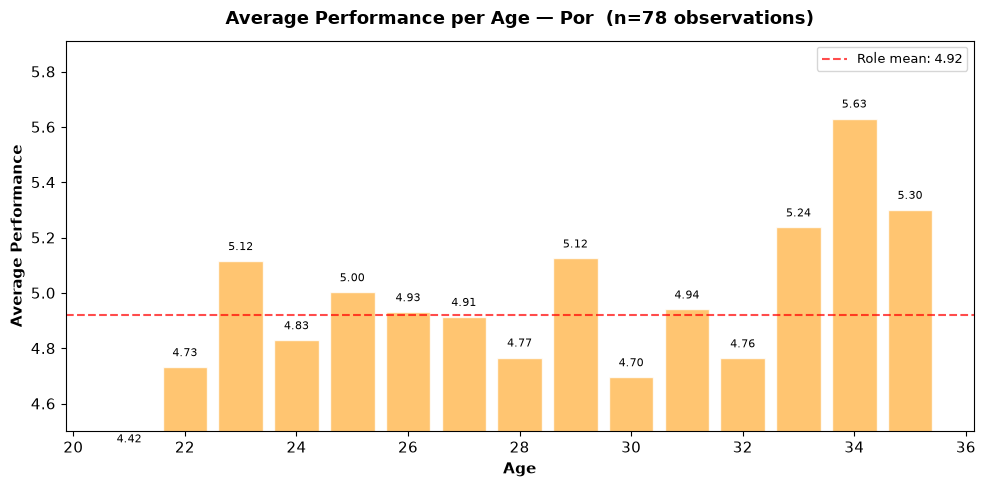

Por: avg perf = 4.92, n=78



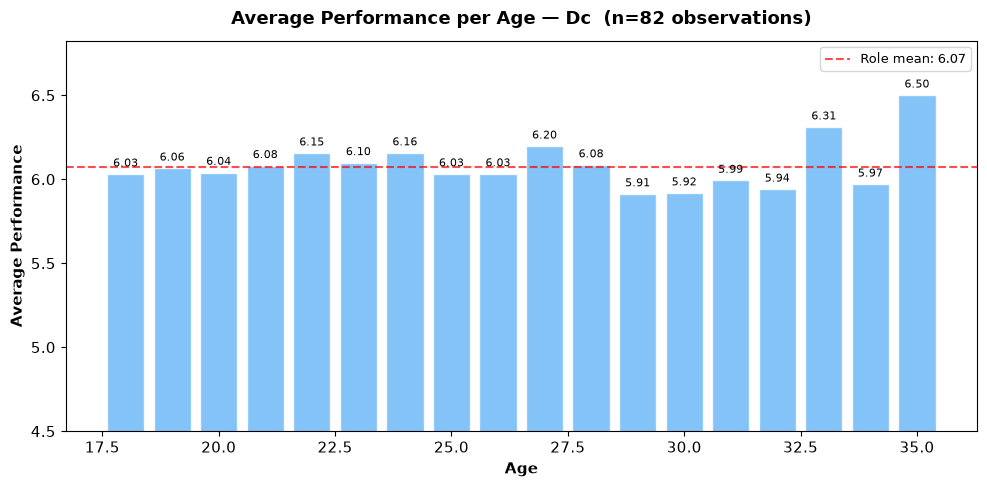

Dc: avg perf = 6.07, n=82



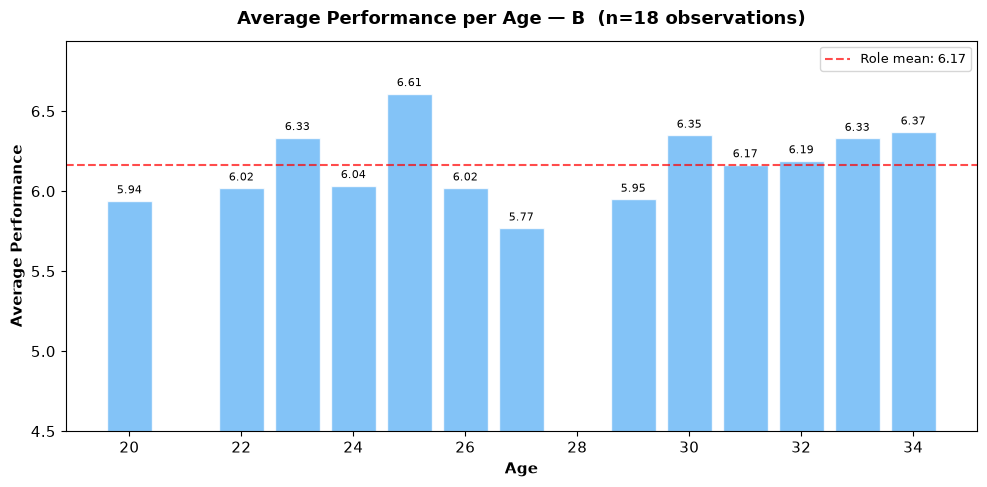

B: avg perf = 6.17, n=18



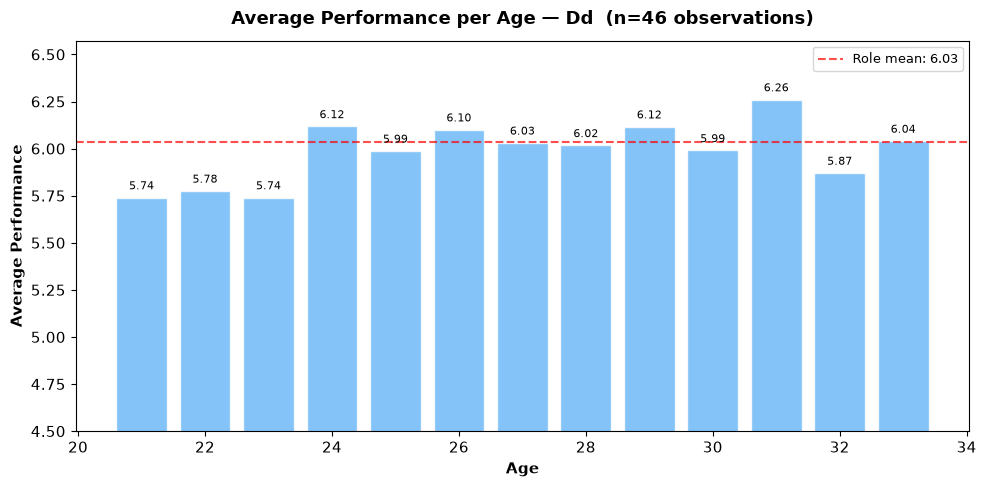

Dd: avg perf = 6.03, n=46



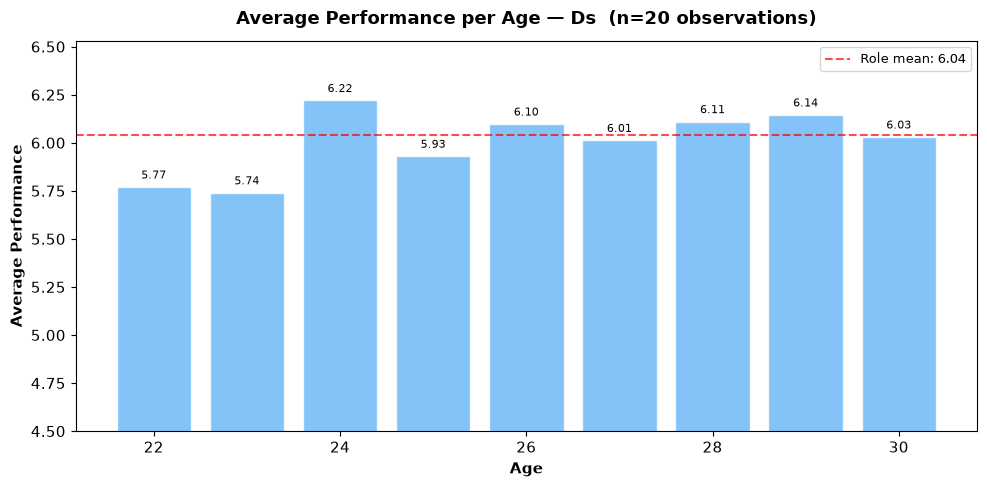

Ds: avg perf = 6.04, n=20



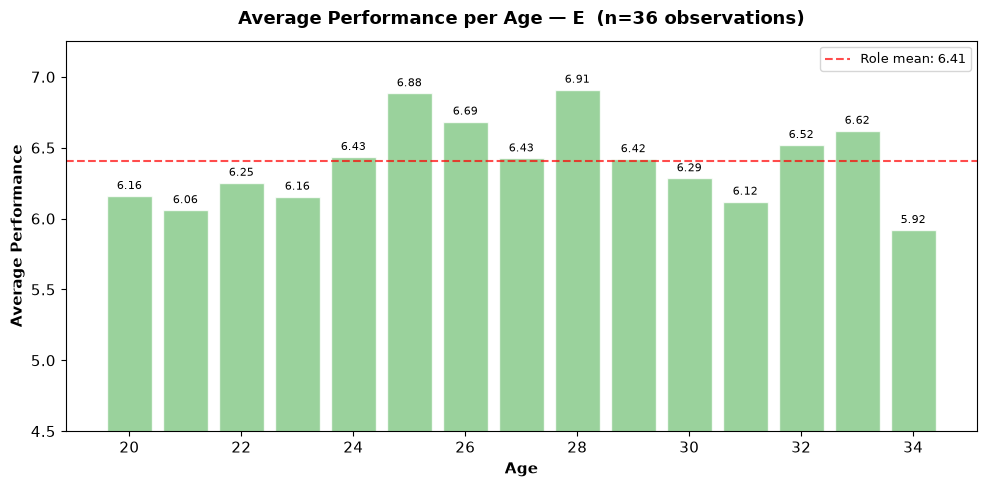

E: avg perf = 6.41, n=36



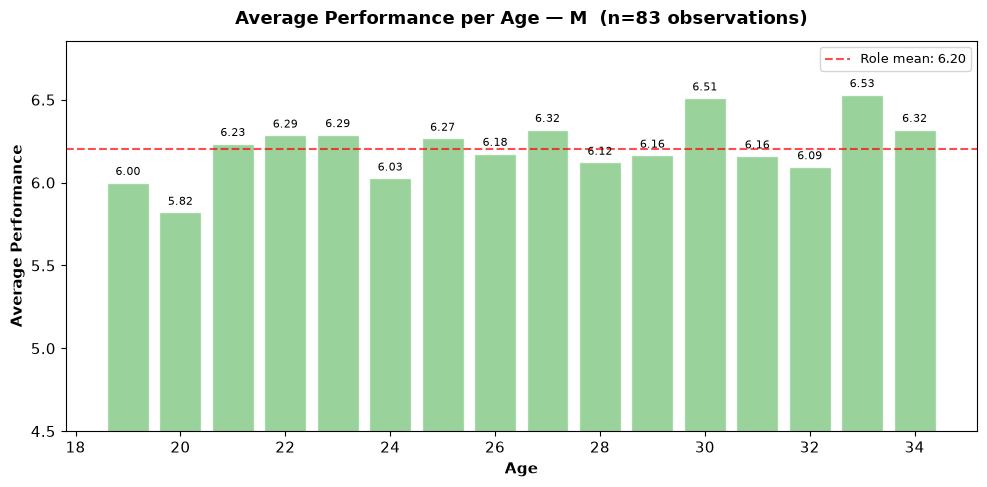

M: avg perf = 6.20, n=83



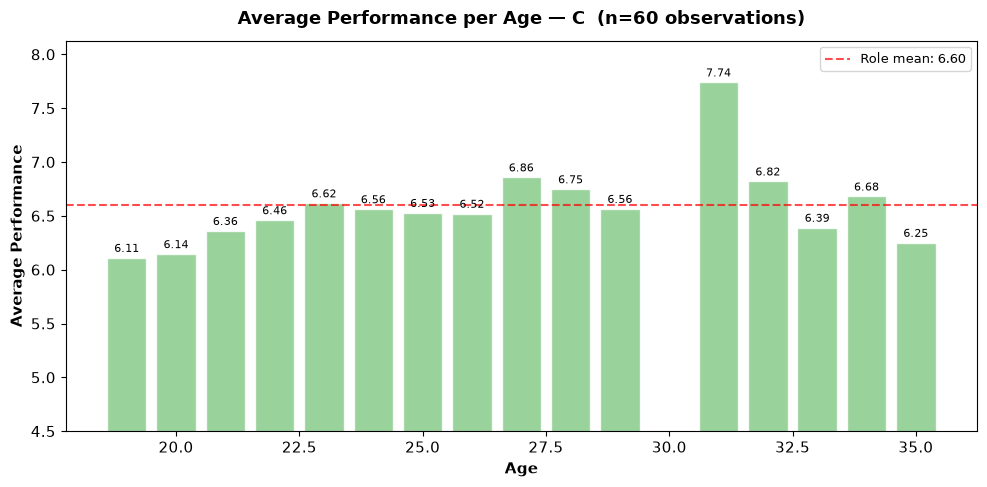

C: avg perf = 6.60, n=60



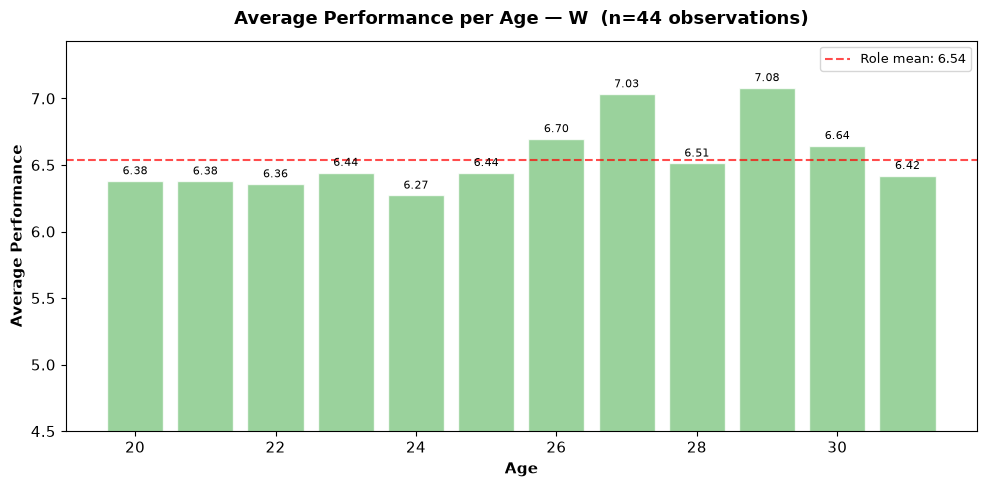

W: avg perf = 6.54, n=44



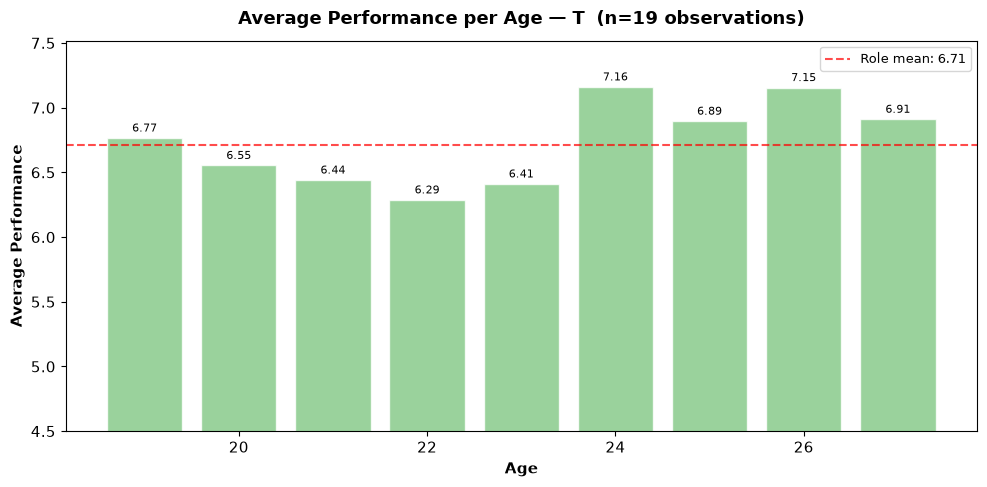

T: avg perf = 6.71, n=19



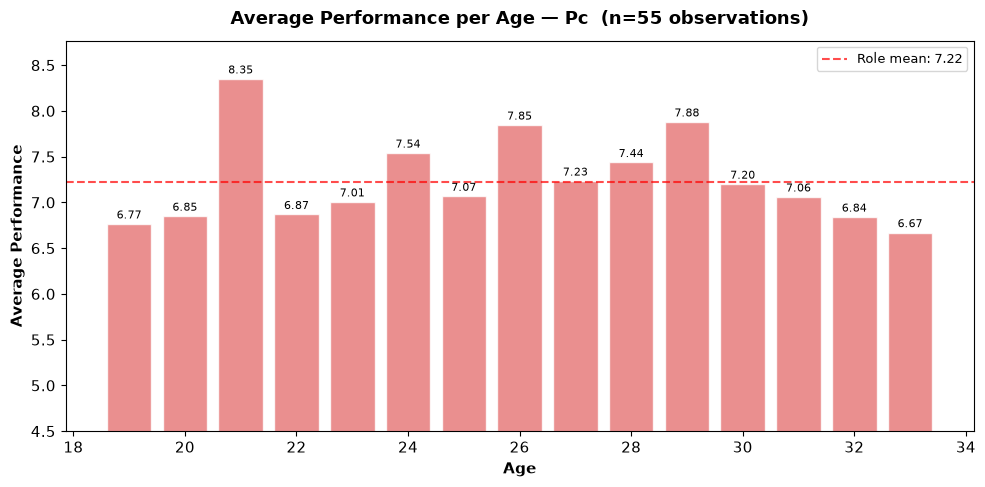

Pc: avg perf = 7.22, n=55



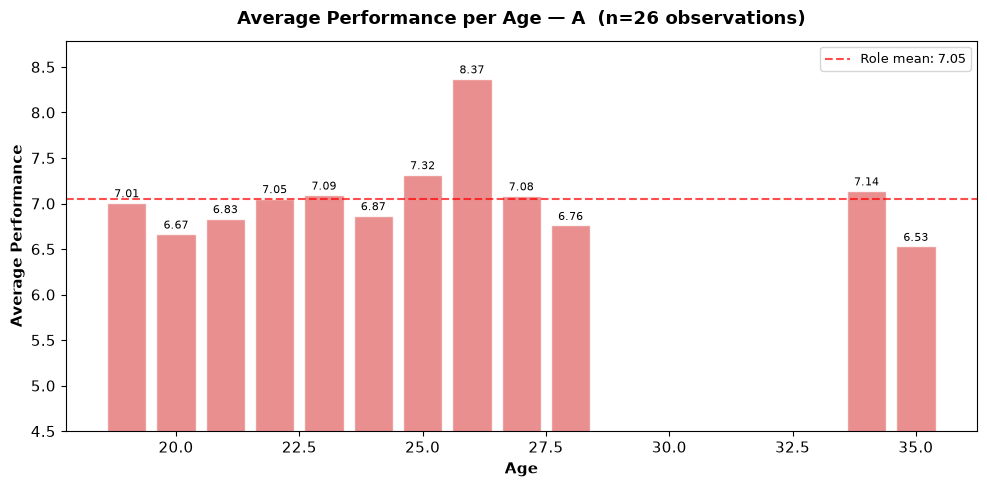

A: avg perf = 7.05, n=26



In [6]:
# Age-performance histograms per Role_M
for i, df_temp in enumerate(df_m):
    role = roles_m[i]
    color = get_role_color(role)
    players = []
    for _, row in df_temp.iterrows():
        for k, s in enumerate(seasons):
            if row['Pg'+s] >= matches_filter[i]:
                players.append({'Name': row['Name'], 'Age': row['Age']-1-k, 'MfPerformance': row['Mf'+s]})
    new_df = pd.DataFrame(players)
    if len(new_df) == 0:
        continue
    avg = new_df.groupby('Age')['MfPerformance'].mean()
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(avg.index, avg.values, color=color, edgecolor='white', alpha=0.8)
    ax.set_ylim(bottom=4.5)
    ax.set_xlabel('Age', fontweight='bold')
    ax.set_ylabel('Average Performance', fontweight='bold')
    ax.set_title(f'Average Performance per Age — {role}  (n={len(new_df)} observations)', fontweight='bold', pad=12)
    # Annotate bars with values
    for bar, val in zip(bars, avg.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    # Add mean line
    ax.axhline(new_df['MfPerformance'].mean(), color='red', linestyle='--', alpha=0.7,
                label=f"Role mean: {new_df['MfPerformance'].mean():.2f}")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f'{role}: avg perf = {new_df["MfPerformance"].mean():.2f}, n={len(new_df)}')
    print()




## Polynomial curve fits

Quadratic polynomial fitted to age-performance averages. Used to compute the age delta modifier for ExpectedMf.

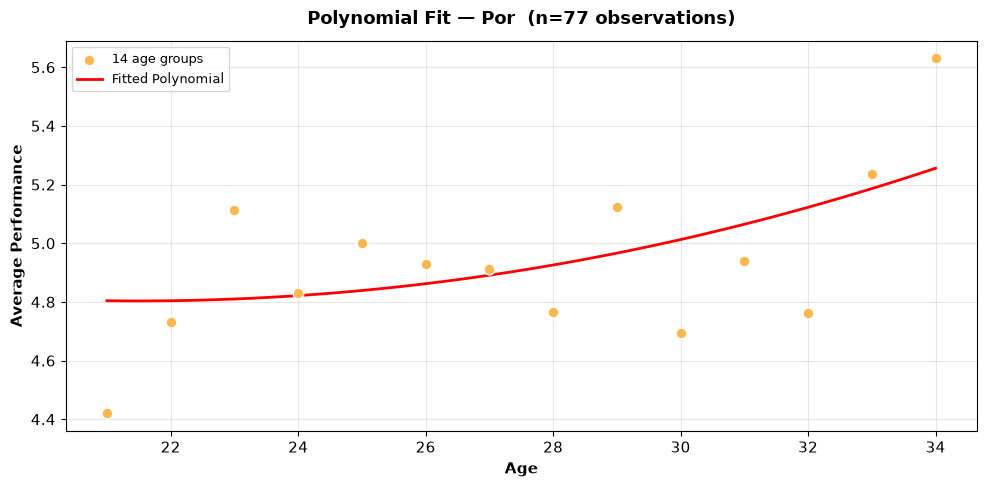

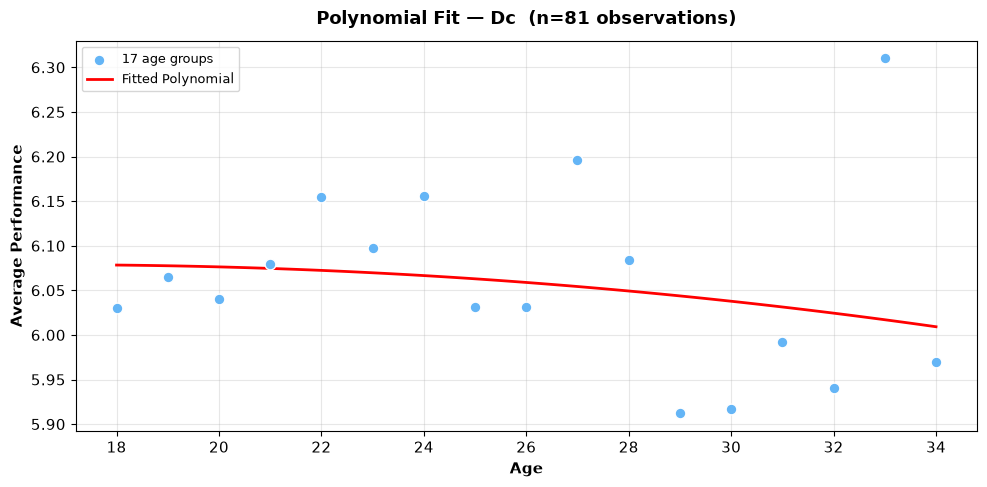

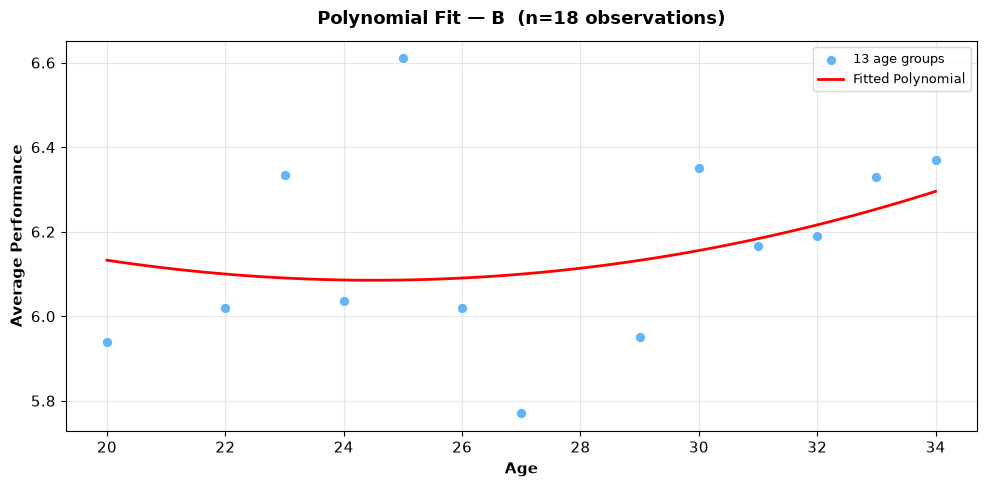

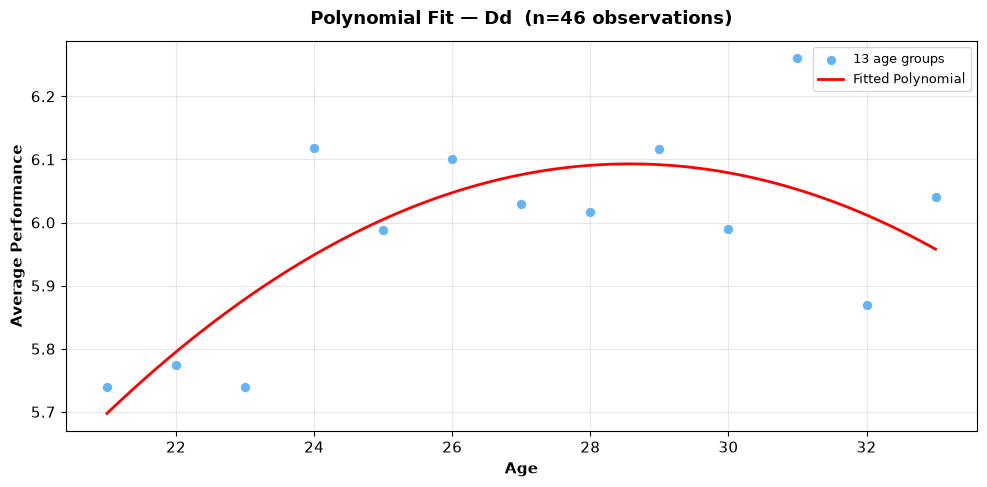

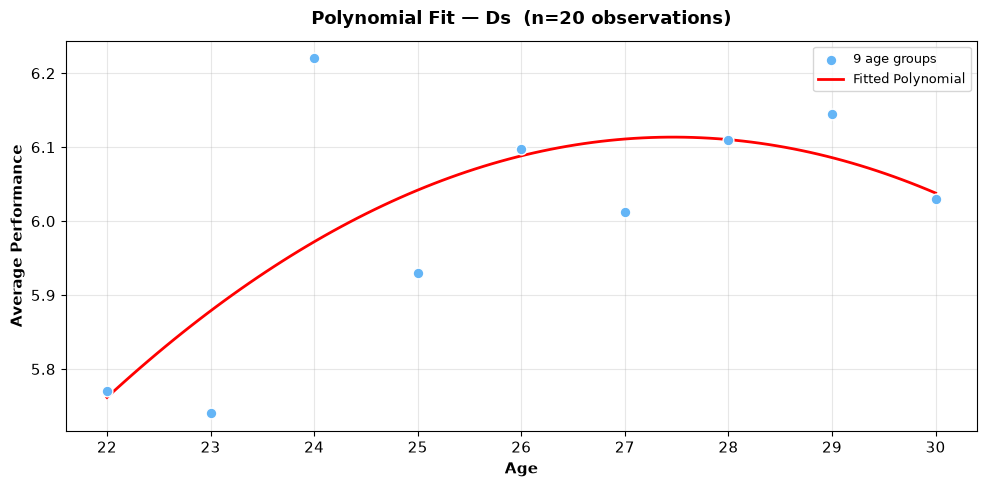

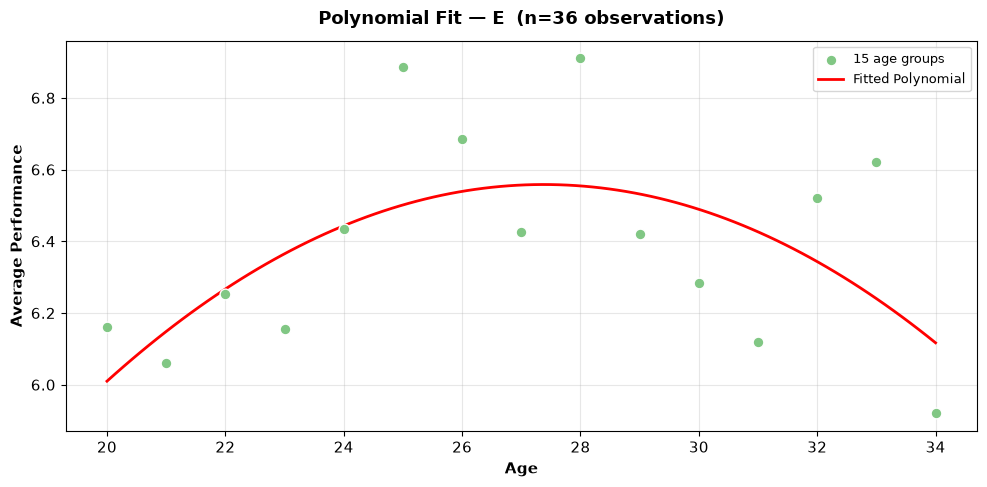

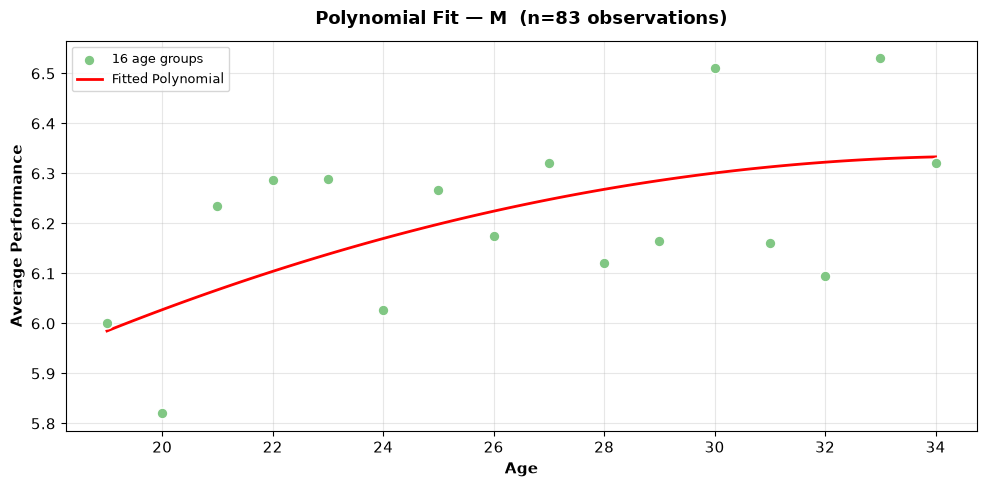

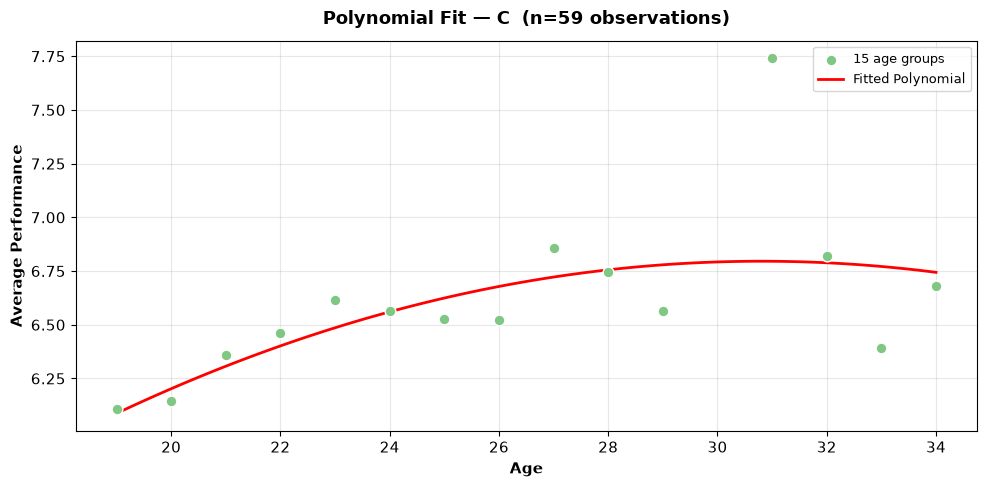

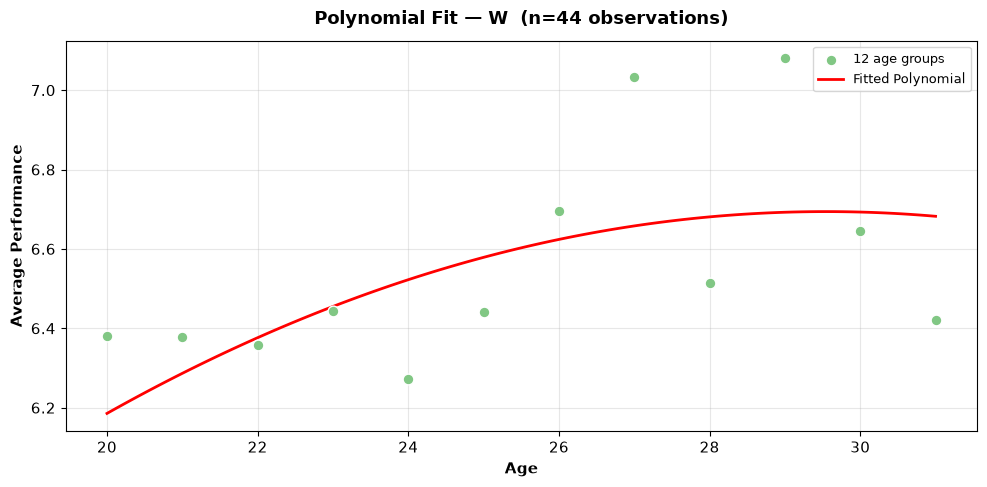

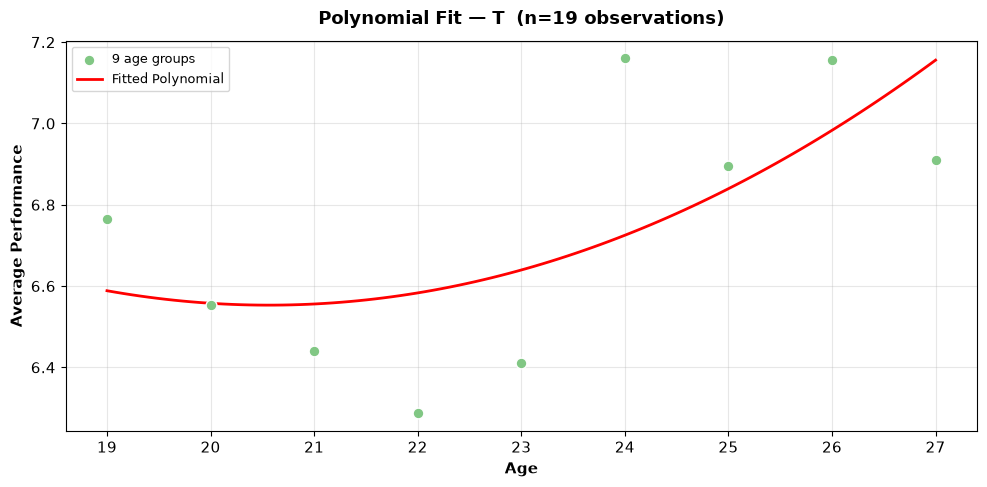

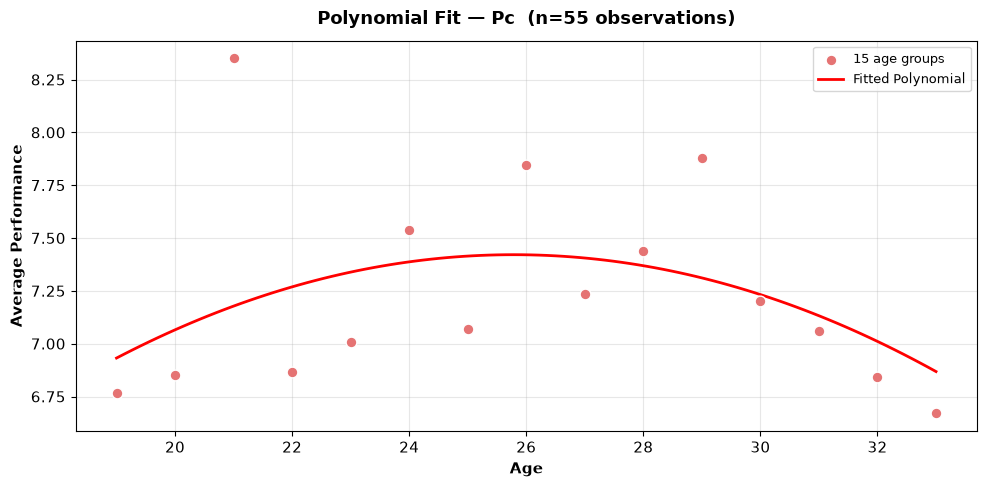

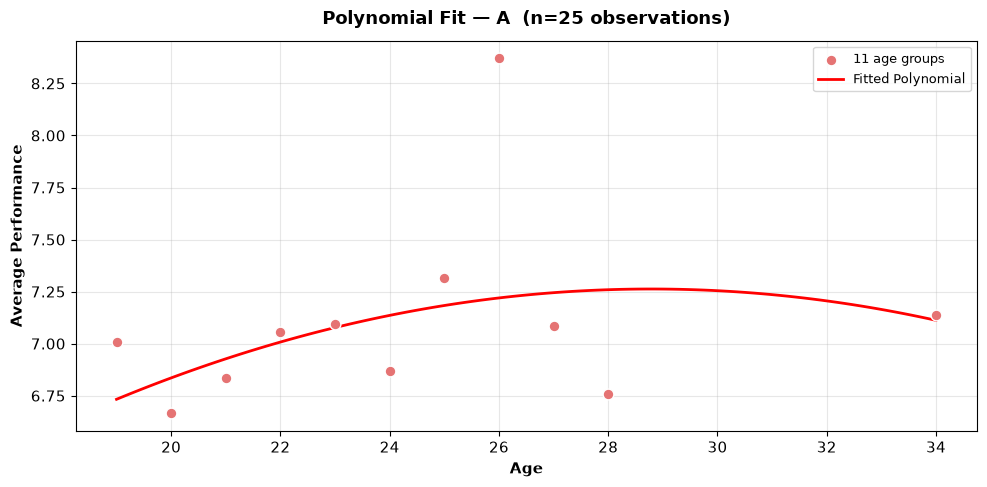

In [7]:
# Polynomial curve fits (age-performance)
for i, p in enumerate(stats_models):
    if p is None:
        continue
    role = roles_m[i]
    color = get_role_color(role)
    df_temp = df_m[i]
    players = []
    for _, row in df_temp.iterrows():
        for k, s in enumerate(seasons):
            if row['Pg'+s] >= matches_filter[i]:
                players.append({'Name': row['Name'], 'Age': row['Age']-1-k, 'MfPerformance': row['Mf'+s]})
    new_df = pd.DataFrame(players)
    new_df = new_df[new_df['Age'] <= 34]
    avg = new_df.groupby('Age')['MfPerformance'].mean()
    x_fit = np.linspace(min(avg.index), max(avg.index), 100)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(avg.index, avg.values, color=color, s=60, edgecolors='white', zorder=3, label=f'{len(avg)} age groups')
    ax.plot(x_fit, p(x_fit), 'r-', linewidth=2, label='Fitted Polynomial')
    ax.set_xlabel('Age', fontweight='bold')
    ax.set_ylabel('Average Performance', fontweight='bold')
    ax.set_title(f'Polynomial Fit — {role}  (n={len(new_df)} observations)', fontweight='bold', pad=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()




## FVM-performance histograms

Average Mf performance grouped by FVM value (current season only). Shows how FVM translates to actual performance per role.

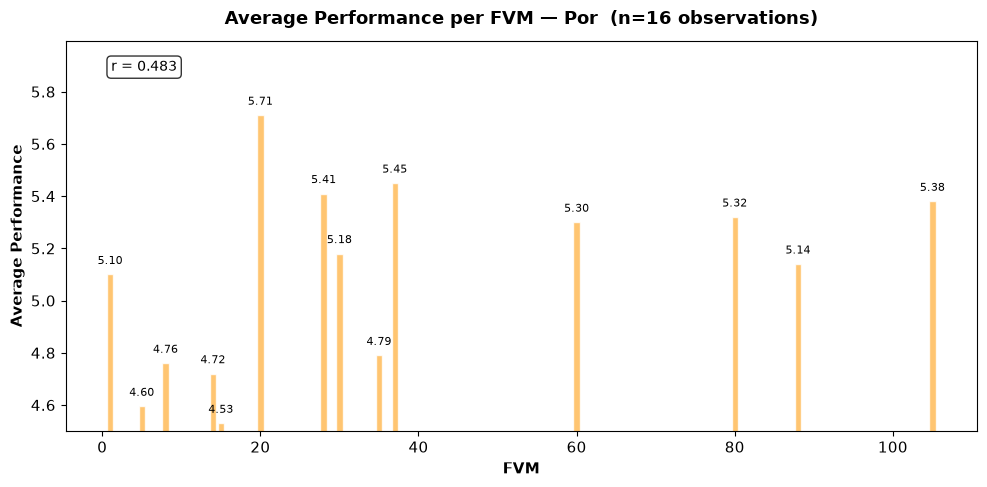

Por: FVM-Mf correlation = 0.483, n=16



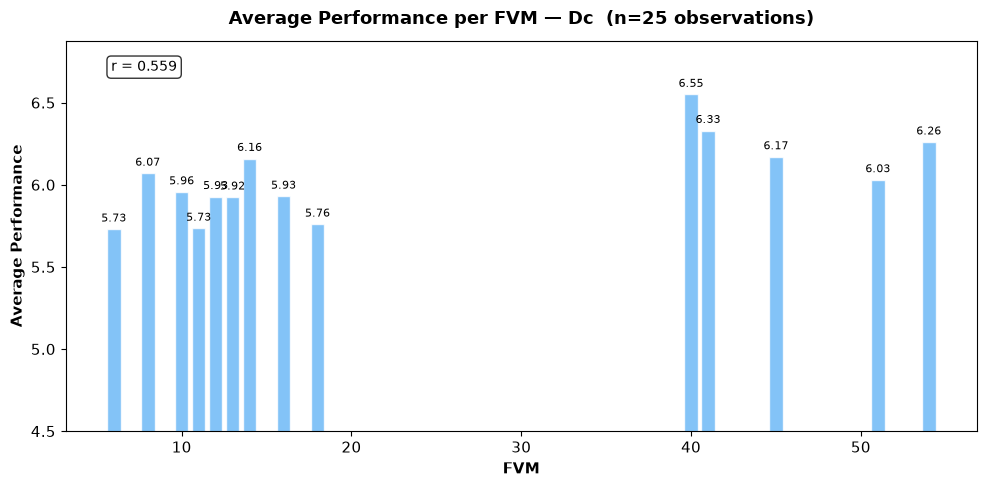

Dc: FVM-Mf correlation = 0.559, n=25



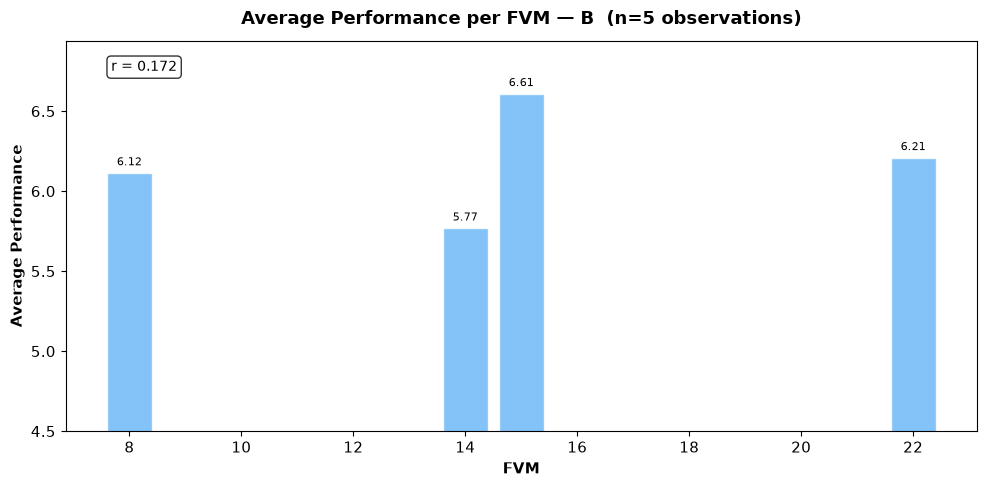

B: FVM-Mf correlation = 0.172, n=5



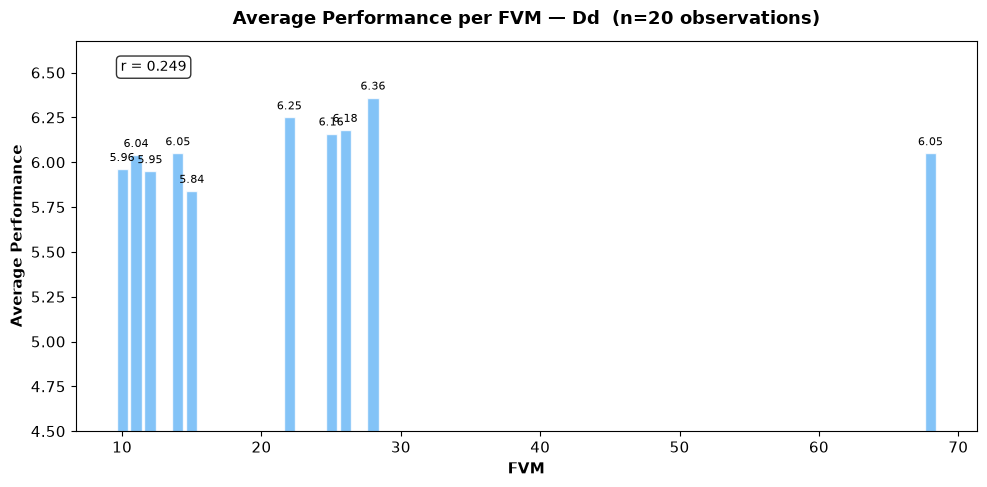

Dd: FVM-Mf correlation = 0.249, n=20



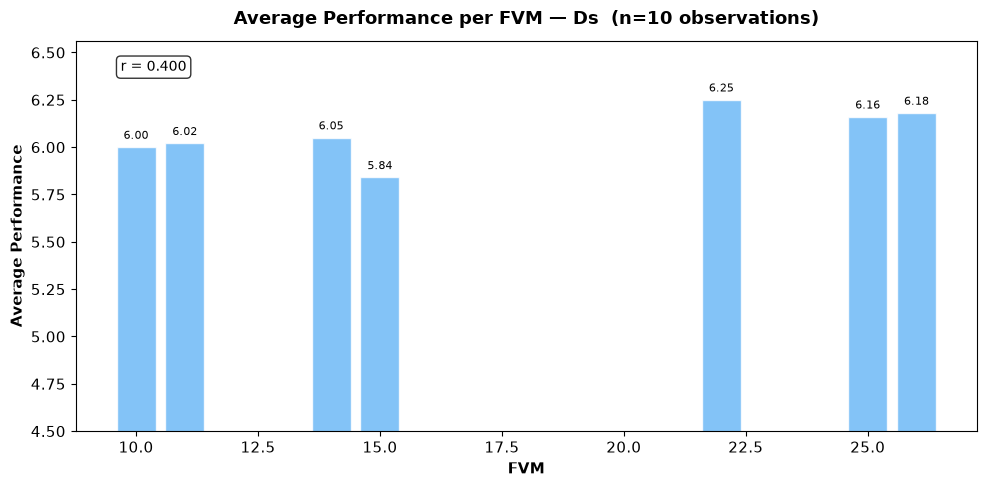

Ds: FVM-Mf correlation = 0.400, n=10



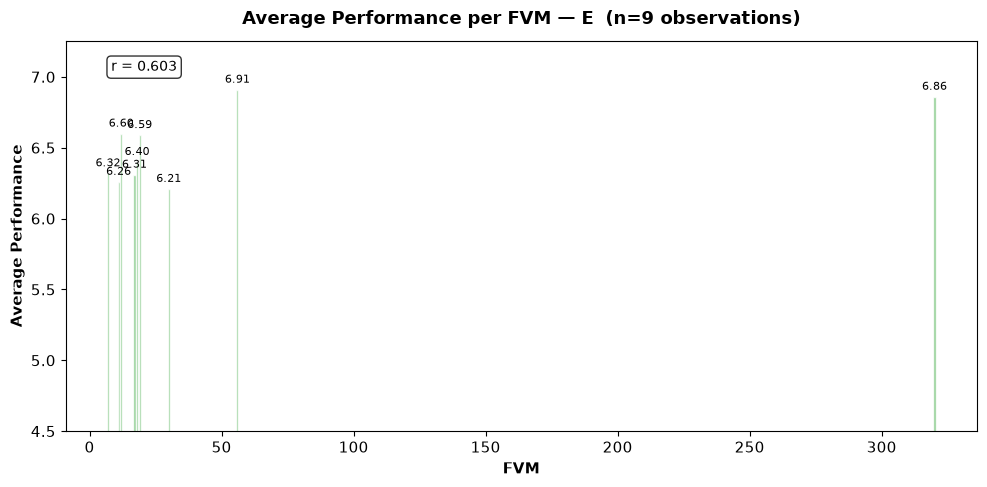

E: FVM-Mf correlation = 0.603, n=9



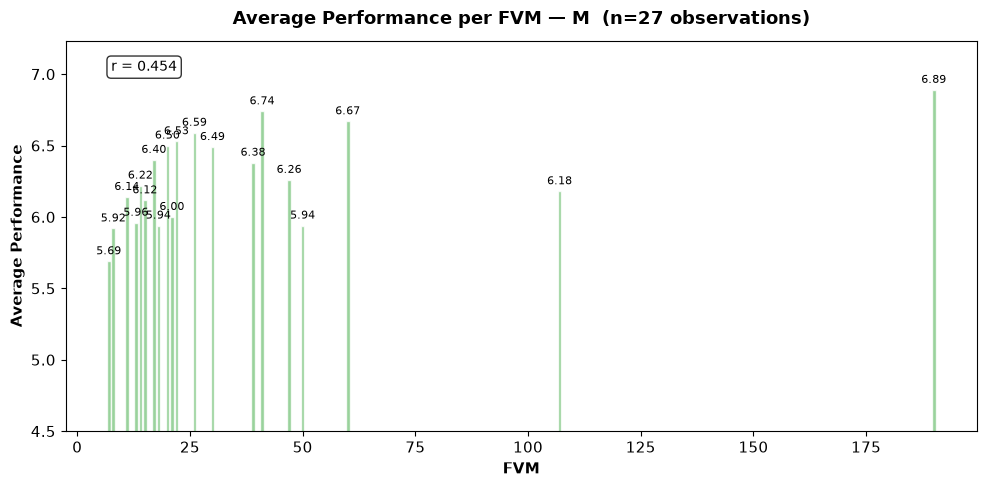

M: FVM-Mf correlation = 0.454, n=27



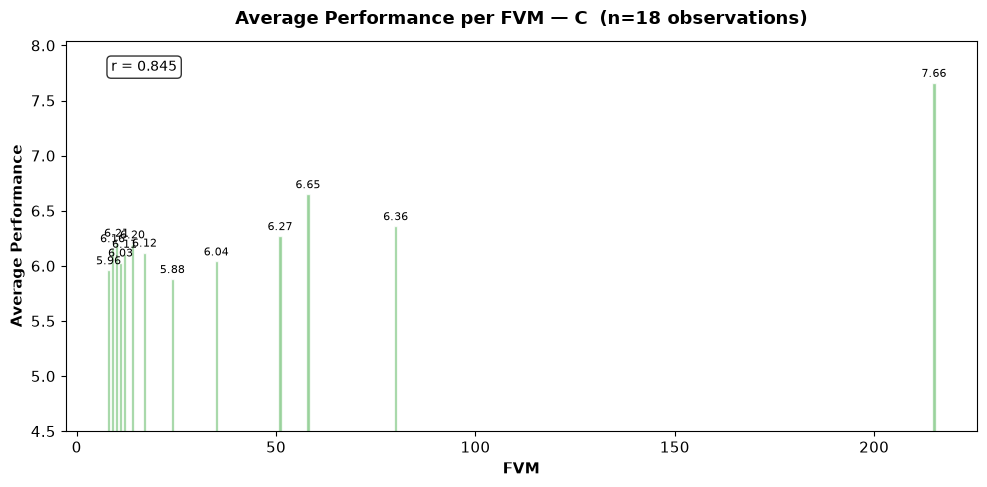

C: FVM-Mf correlation = 0.845, n=18



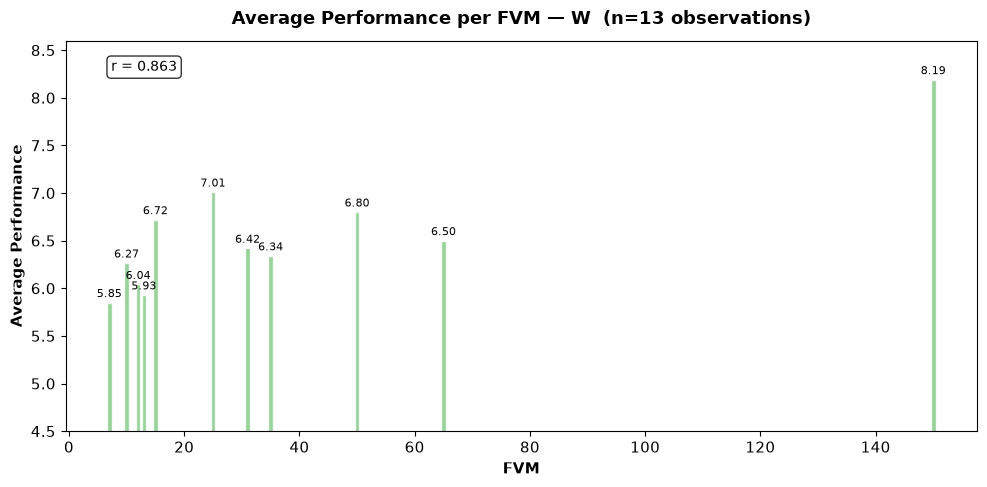

W: FVM-Mf correlation = 0.863, n=13



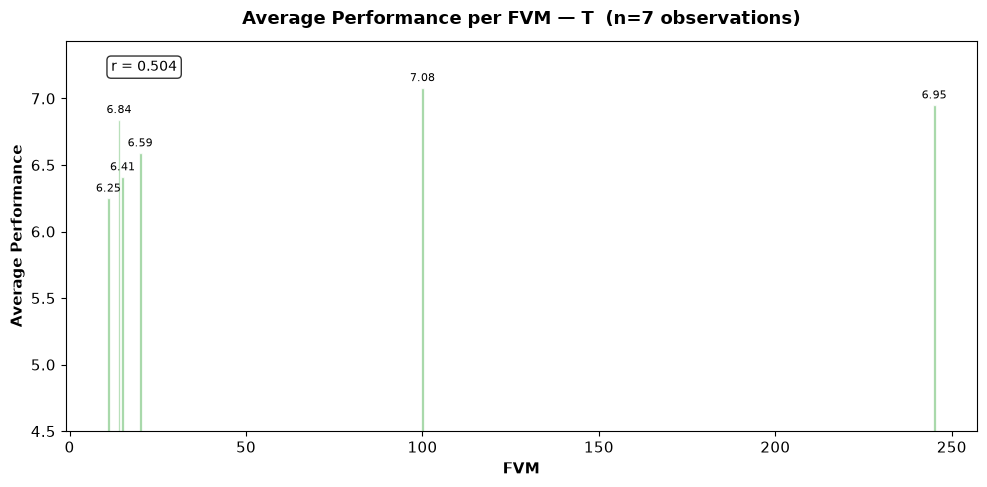

T: FVM-Mf correlation = 0.504, n=7



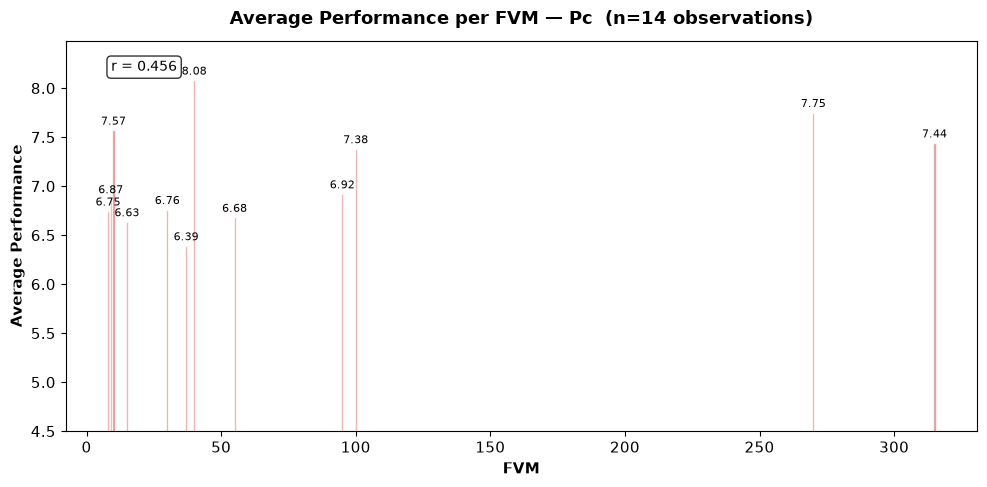

Pc: FVM-Mf correlation = 0.456, n=14



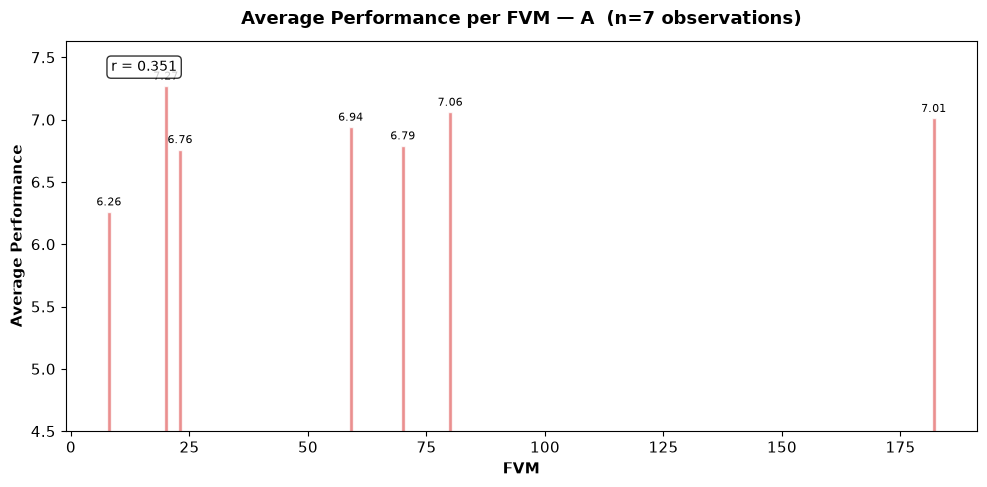

A: FVM-Mf correlation = 0.351, n=7



In [8]:
# FVM-performance histograms
for i, df_temp in enumerate(df_m):
    role = roles_m[i]
    color = get_role_color(role)
    players = []
    for _, row in df_temp.iterrows():
        if row['Pg'+seasons[0]] >= fvm_curve_min_games:
            players.append({'Name': row['Name'], 'FVM': row['FVM'], 'MfPerformance': row['Mf'+seasons[0]]})
    new_df = pd.DataFrame(players)
    if len(new_df) == 0:
        continue
    avg = new_df.groupby('FVM')['MfPerformance'].mean()
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(avg.index, avg.values, color=color, edgecolor='white', alpha=0.8)
    ax.set_ylim(bottom=4.5)
    ax.set_xlabel('FVM', fontweight='bold')
    ax.set_ylabel('Average Performance', fontweight='bold')
    ax.set_title(f'Average Performance per FVM — {role}  (n={len(new_df)} observations)', fontweight='bold', pad=12)
    # Annotate bars
    for bar, val in zip(bars, avg.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    # Add correlation
    corr = np.corrcoef(new_df['FVM'].values, new_df['MfPerformance'].values)[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()
    print(f'{role}: FVM-Mf correlation = {corr:.3f}, n={len(new_df)}')
    print()




## FVM regression plots (tuned)

Pooled same-season FVM → Mf regression across all available FVM seasons.
Models are fitted by the tuning step above using the selected configuration.
Each observation weighted by `clip(Pg, 0, 38)`.

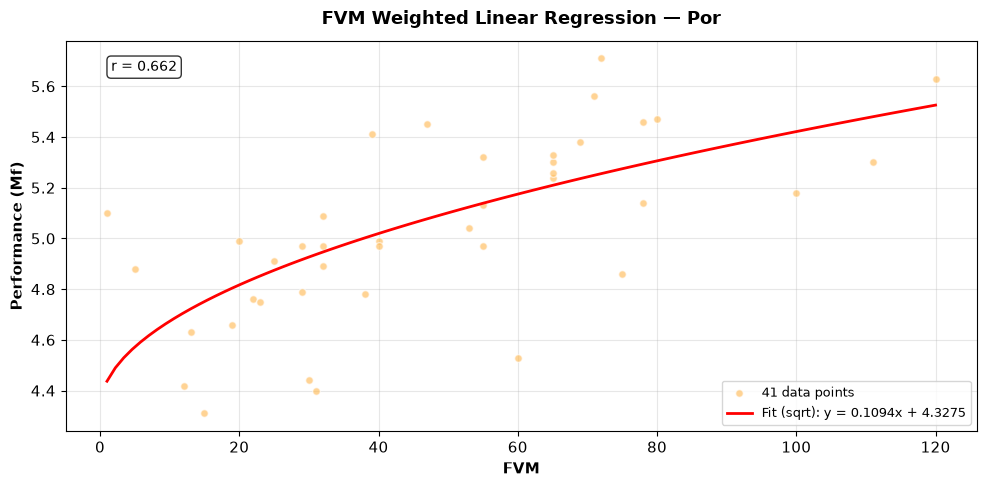

Por: r=0.662, slope=0.1094, intercept=4.3275, n=41



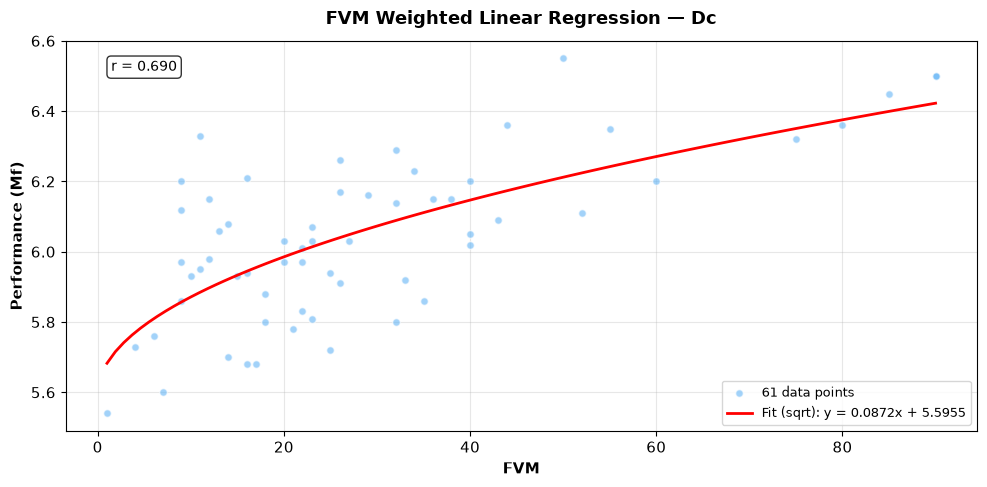

Dc: r=0.690, slope=0.0872, intercept=5.5955, n=61



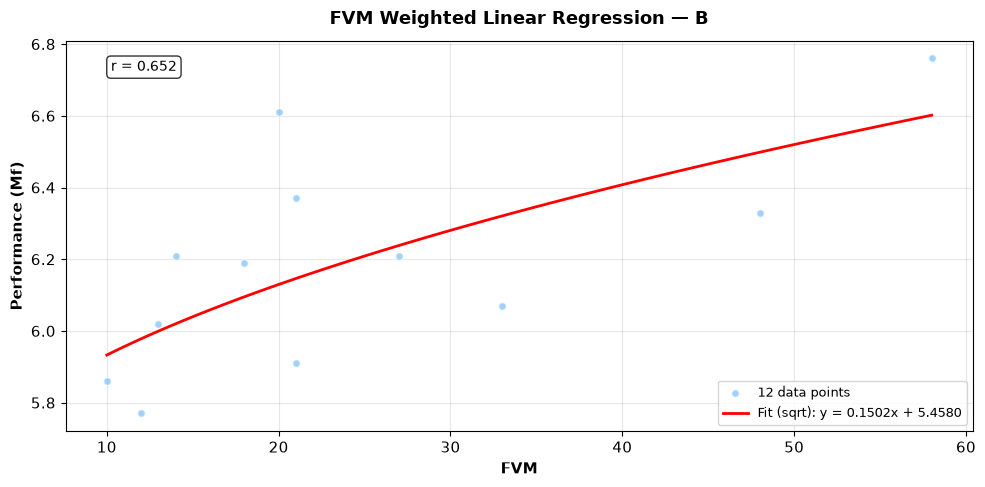

B: r=0.652, slope=0.1502, intercept=5.4580, n=12



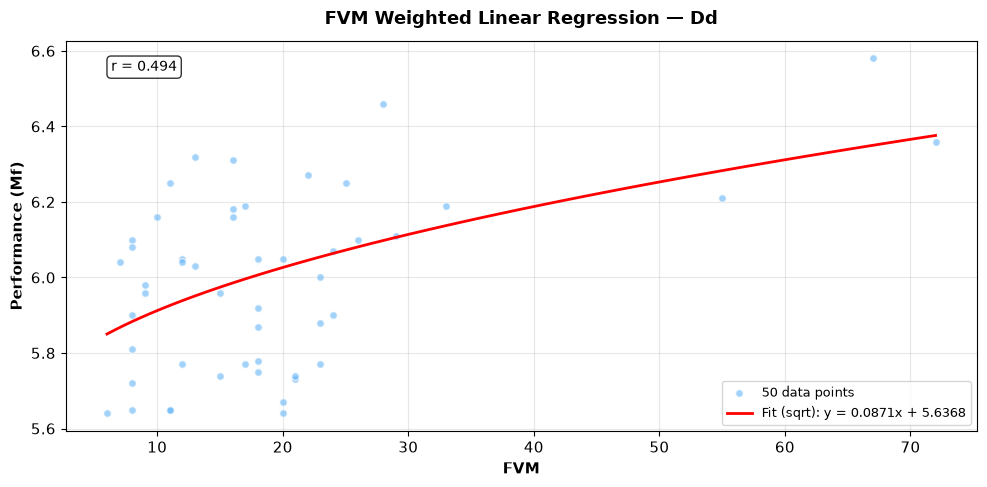

Dd: r=0.494, slope=0.0871, intercept=5.6368, n=50



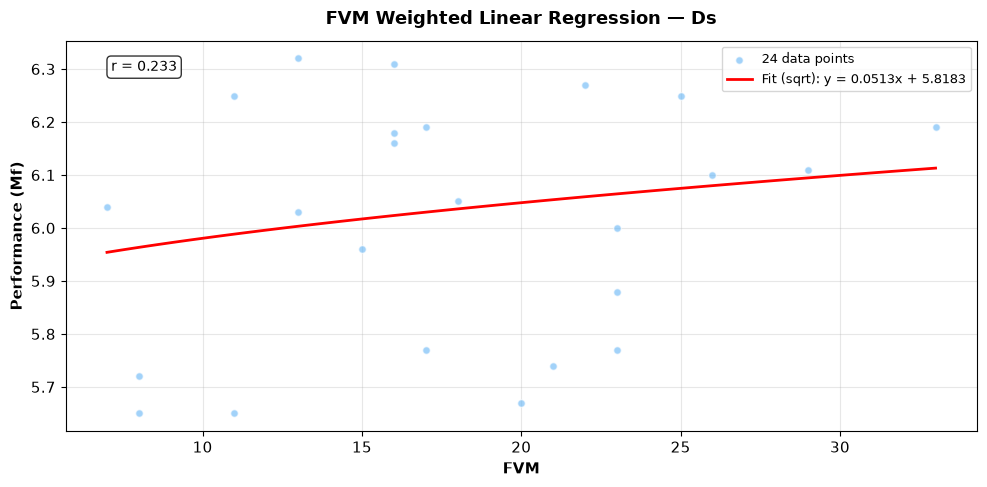

Ds: r=0.233, slope=0.0513, intercept=5.8183, n=24



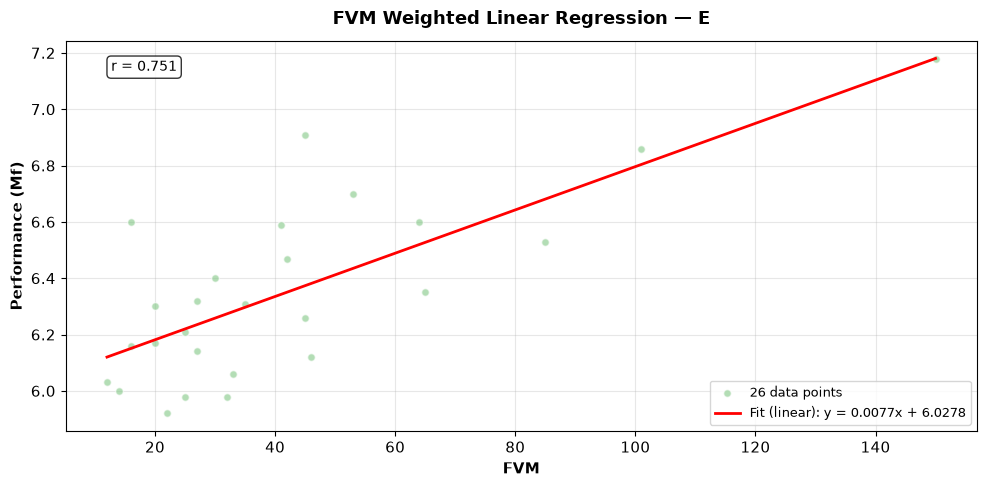

E: r=0.751, slope=0.0077, intercept=6.0278, n=26



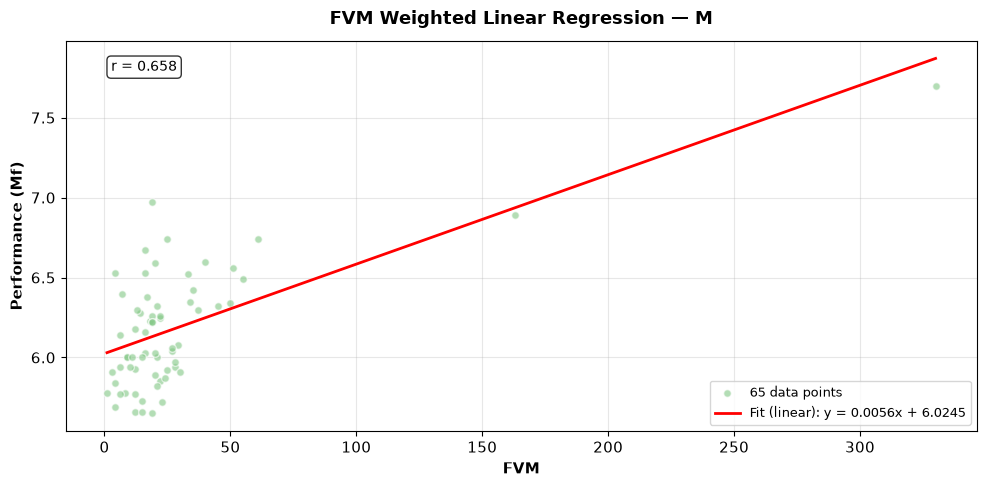

M: r=0.658, slope=0.0056, intercept=6.0245, n=65



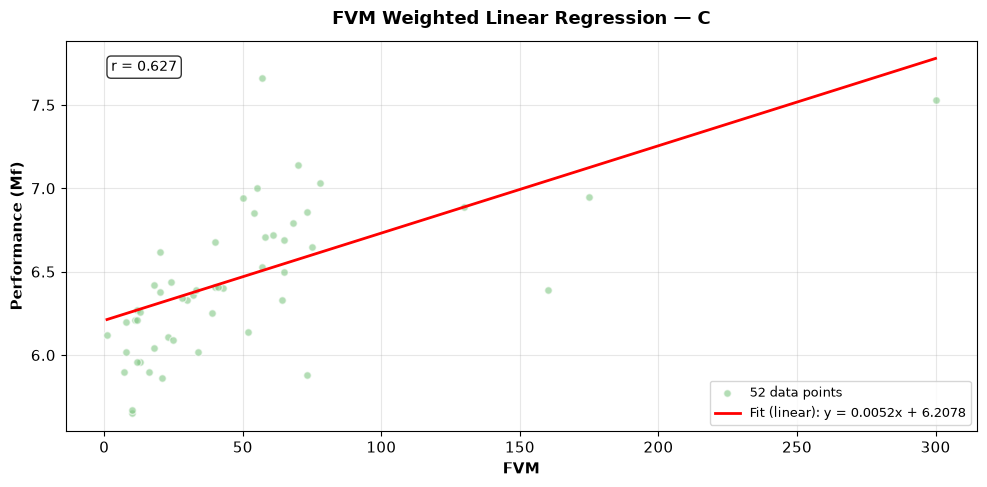

C: r=0.627, slope=0.0052, intercept=6.2078, n=52



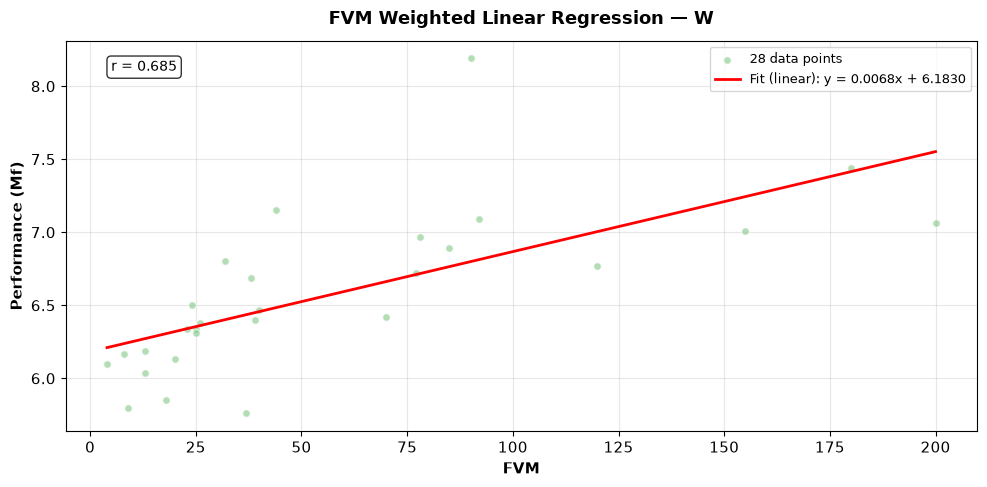

W: r=0.685, slope=0.0068, intercept=6.1830, n=28



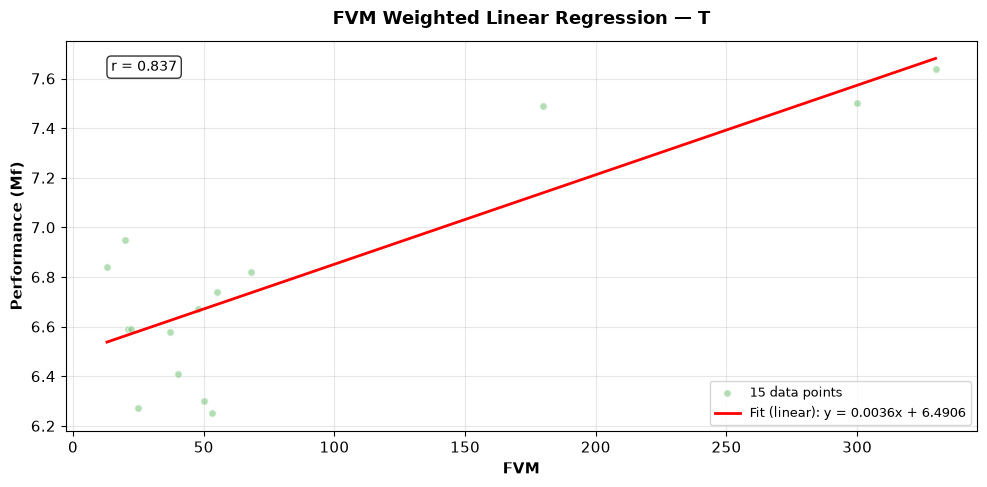

T: r=0.837, slope=0.0036, intercept=6.4906, n=15



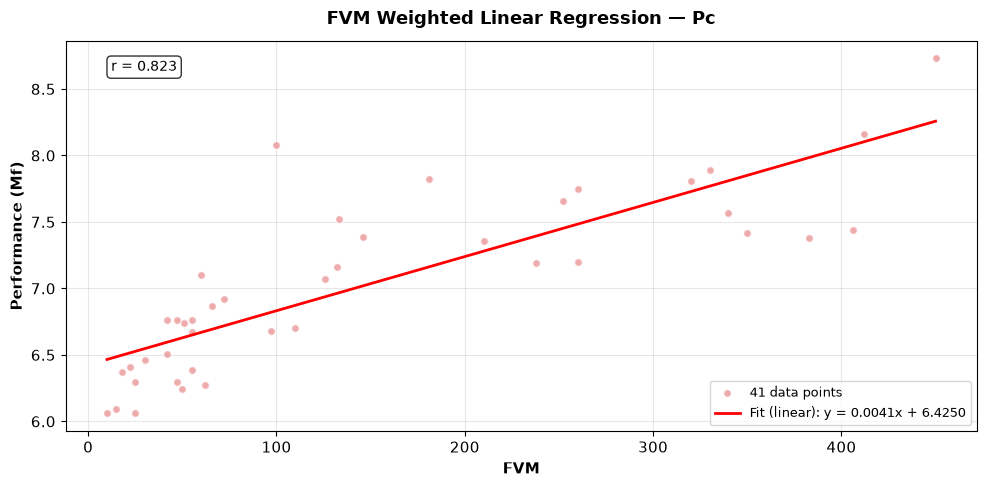

Pc: r=0.823, slope=0.0041, intercept=6.4250, n=41



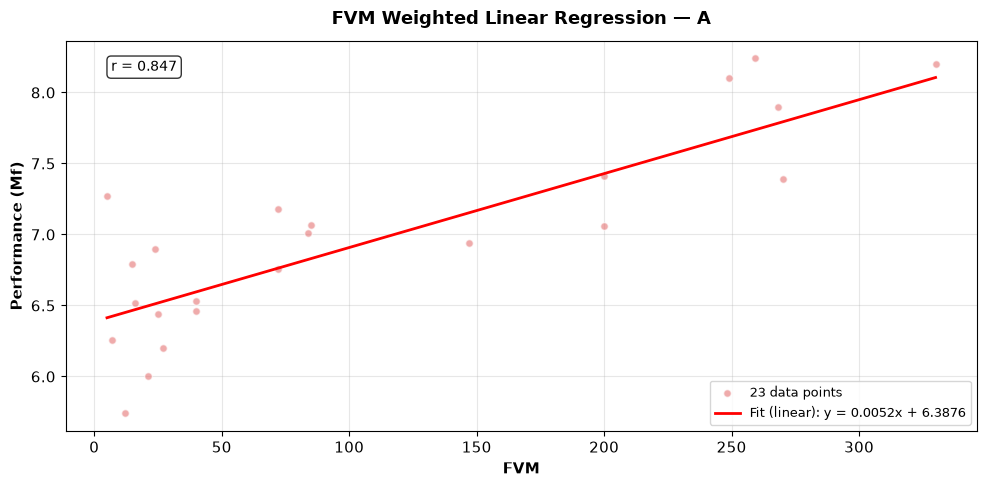

A: r=0.847, slope=0.0052, intercept=6.3876, n=23



In [9]:
# FVM linear regression plots
for i, model in enumerate(fvm_models):
    if model is None:
        continue
    role = roles_m[i]
    color = get_role_color(role)
    df_temp = df_m[i]
    players = []
    for _, row in df_temp.iterrows():
        for j, s in enumerate(seasons):
            fvm_col = f'FVM{s}'
            mf_col = f'Mf{s}'
            pg_col = f'Pg{s}'
            if pg_col in row and mf_col in row and fvm_col in row:
                try:
                    pg_val = row[pg_col]
                    if pd.notna(pg_val) and pg_val >= fvm_curve_min_games:
                        fvm_val = row[fvm_col]
                        mf_val = row[mf_col]
                        if pd.notna(fvm_val) and pd.notna(mf_val) and fvm_val > 0 and mf_val > 0:
                            players.append({'Name': row['Name'], 'FVM': fvm_val, 'MfPerformance': mf_val})
                except Exception:
                    pass
    new_df = pd.DataFrame(players)
    if len(new_df) == 0:
        continue
    x_min, x_max = new_df['FVM'].min(), new_df['FVM'].max()
    myline = np.linspace(x_min, x_max, 100)
    # Resolve transform for this role
    role_major = {'Por':'P','Dc':'D','B':'D','Dd':'D','Ds':'D','E':'C','M':'C','C':'C','W':'C','T':'C','Pc':'A','A':'A'}.get(role, 'C')
    role_transform = fvm_transform.get(role_major, fvm_transform) if isinstance(fvm_transform, dict) else fvm_transform
    # Apply inverse transform for plotting: model was fitted on transformed FVM
    myline_x = transform_fvm(myline, role_transform)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(new_df['FVM'], new_df['MfPerformance'], color=color, s=30, alpha=0.6, edgecolors='white', zorder=2,
               label=f'{len(new_df)} data points')
    ax.plot(myline, np.polyval(model, myline_x), 'r-', linewidth=2,
            label=f'Fit ({role_transform}): y = {model[0]:.4f}x + {model[1]:.4f}', zorder=3)
    ax.set_xlabel('FVM', fontweight='bold')
    ax.set_ylabel('Performance (Mf)', fontweight='bold')
    ax.set_title(f'FVM Weighted Linear Regression — {role}', fontweight='bold', pad=12)
    # Correlation
    corr = np.corrcoef(new_df['FVM'].values, new_df['MfPerformance'].values)[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'{role}: r={corr:.3f}, slope={model[0]:.4f}, intercept={model[1]:.4f}, n={len(new_df)}')
    print()







## Spot check — key players


In [10]:
for name in ['Malen','Martinez L.', 'Hojlund', 'Yildiz', 'Raspadori', 'Nkunku', 'Paz N.', 'Orsolini', 'Calhanoglu', 'Baturina', 'Pulisic', 'Zaniolo', 'Sommer', 'Dimarco', 'Palestra', 'Dumfries', 'Bremer']:
    row = df[df['Name']==name]
    if not row.empty:
        print(f"{name}: ExpectedMf={row['ExpectedMf'].values[0]}")


Malen: ExpectedMf=8.34
Martinez L.: ExpectedMf=7.96
Hojlund: ExpectedMf=7.58
Yildiz: ExpectedMf=7.57
Raspadori: ExpectedMf=6.98
Nkunku: ExpectedMf=7.0
Paz N.: ExpectedMf=7.58
Orsolini: ExpectedMf=7.7
Calhanoglu: ExpectedMf=7.33
Baturina: ExpectedMf=7.06
Pulisic: ExpectedMf=7.26
Zaniolo: ExpectedMf=7.01
Sommer: ExpectedMf=5.21
Dimarco: ExpectedMf=8.5
Palestra: ExpectedMf=6.75
Dumfries: ExpectedMf=6.81
Bremer: ExpectedMf=6.48


## MyRating — auto-derived 1–5 vote (BE contract)

The FE displays the rating, so `myrating` must be present in `output_rp.csv` (and thus in the
final BE CSV). It was auto-computed in the legacy ratings notebook and dropped in the Stage 01
refactor; it is restored here as a deterministic derivation of `ExpectedMf`.

Mapping (closed form, per major role, on the old absolute scale):

```
z = (ExpectedMf - mean_role) / std_role          # pooled historical Mf, Pg >= age_min_games
MyRating = round(clip(1 + (z + 4) / 6.5 * 4, 1, 5), 1)    # z in [-4, 2.5] -> [1, 5]
```

No manual step. See `docs/phase3_stage2a2b_plan.md` (prerequisite P1).


In [11]:
# ---------------------------------------------------------------------------
# MyRating — auto-derived 1-5 "vote" for the BE contract (see markdown above)
# ---------------------------------------------------------------------------
mf_cols = [c for c in df.columns if c.startswith('Mf') and c != 'ExpectedMf']

role_mf_stats = {}
for role in roles:
    pool = pd.concat([
        df[(df['Role'] == role) & (df[mf_c.replace('Mf', 'Pg')] >= age_pred_min_games)][mf_c]
        for mf_c in mf_cols
    ]).dropna()
    role_mf_stats[role] = (float(pool.mean()), float(pool.std()))
    print(f"{role}: historical Mf pool n={len(pool)}, mean={pool.mean():.3f}, std={pool.std():.3f}")

def to_myrating(expected_mf, role):
    """Map ExpectedMf to the 1-5 rating scale (z in [-4, 2.5] -> [1, 5])."""
    mean, std = role_mf_stats[role]
    z = (expected_mf - mean) / std
    return round(min(max(1 + (z + 4) / 6.5 * 4, 1.0), 5.0), 1)

df.insert(list(df.columns).index('FVM'), 'MyRating',
          [to_myrating(m, r) for m, r in zip(df['ExpectedMf'], df['Role'])])
print(f"MyRating: min={df['MyRating'].min()}, max={df['MyRating'].max()}, mean={df['MyRating'].mean():.2f}")


P: historical Mf pool n=69, mean=4.929, std=0.388
D: historical Mf pool n=304, mean=6.065, std=0.314
C: historical Mf pool n=315, mean=6.359, std=0.466
A: historical Mf pool n=150, mean=6.964, std=0.702
MyRating: min=2.8, max=5.0, mean=3.57


## Validation

Checks that ExpectedMf values fall within plausible bounds per role:
- **P**: 3.0 — 6.0
- **D**: 4.0 — 7.5
- **C**: 4.0 — 9.0
- **A**: 4.5 — 10.0

Also checks `MyRating` (auto-derived, see above): all values within [1, 5].


In [12]:
# Bounds loaded from config
bounds = {k: tuple(v) for k, v in CFG['expected_mf_bounds'].items()}

report = {}
for role, (lo, hi) in bounds.items():
    vals = df.loc[df['Role'] == role, 'ExpectedMf']
    report[role] = {
        'count': int(len(vals)),
        'mean': float(vals.mean()),
        'out_of_bounds': int(((vals < lo) | (vals > hi)).sum())
    }
mr = df['MyRating'].dropna()
report['myrating_ok'] = bool(((mr >= 1) & (mr <= 5)).all())
report['myrating_mean'] = float(mr.mean())
report['myrating_missing'] = int(df['MyRating'].isna().sum())

with open(f"{INTER_DIR}/validation_stage1.json", "w") as f:
    json.dump(report, f, indent=2)
print(json.dumps(report, indent=2))

{
  "P": {
    "count": 67,
    "mean": 4.67328358208955,
    "out_of_bounds": 0
  },
  "D": {
    "count": 184,
    "mean": 6.190326086956522,
    "out_of_bounds": 1
  },
  "C": {
    "count": 178,
    "mean": 6.560842696629213,
    "out_of_bounds": 0
  },
  "A": {
    "count": 103,
    "mean": 6.900291262135923,
    "out_of_bounds": 0
  },
  "myrating_ok": true,
  "myrating_mean": 3.5657894736842106,
  "myrating_missing": 0
}


In [13]:
df.to_csv(OUTPUT_PATH, index=False)
